# Define variables

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # disable tensorflow cuda warning messages
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # force deterministic TF ops

root_dir = './'
dataset_dir = os.path.join(root_dir, 'datasets')
dataset_dir_noisy = os.path.join(dataset_dir, 'normal')
dataset_dir_clean = os.path.join(dataset_dir, 'delay')

features_path_clean = os.path.join(dataset_dir, 'features-clean.npz')
features_path_noisy = os.path.join(dataset_dir, 'features-noisy.npz')
features_path_mixed = os.path.join(dataset_dir, 'features-mixed.npz')

model_dir = os.path.join(root_dir, 'models-150')
os.makedirs(model_dir, exist_ok=True)

cnn_model_path_clean = os.path.join(model_dir, 'cnn_model-clean')
cnn_model_path_noisy = os.path.join(model_dir, 'cnn_model-noisy')
cnn_model_path_mixed = os.path.join(model_dir, 'cnn_model-mixed')

svm_model_dir = os.path.join(model_dir, 'svm_model')
os.makedirs(svm_model_dir, exist_ok=True)

svm_model_path = os.path.join(svm_model_dir, 'model.pkl')
svm_encoder_path = os.path.join(svm_model_dir, 'label_encoder.pkl')

# Ignore cells function
from IPython.core.magic import register_cell_magic
from IPython import get_ipython

@register_cell_magic
def skip_if(line, cell):
  if eval(line, get_ipython().user_ns):
    print(f"Skipped cell because {line}")
    return
  get_ipython().run_cell(cell)

SKIP_CNN_TRAINING = False
SKIP_CNN_KFOLD = True
SKIP_SVM_TRAINING = False
SKIP_SVM_KFOLD = True
SKIP_SVM_GRIDSEARCH = True
SKIP_NOISY_TESTS = False

# Global random state
RANDOM_STATE = 42
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)

import random
import numpy as np
import tensorflow as tf

def set_random_seed(seed):
  random.seed(RANDOM_STATE)
  np.random.seed(RANDOM_STATE)
  tf.random.set_seed(RANDOM_STATE)


# CQT Feature Extraction



## Clean dataset

In [2]:
import warnings
from tqdm.notebook import tqdm
import numpy as np
import os # Import os for path manipulation
import librosa # Keep librosa import for potential future use or if file doesn't exist

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

features = []
labels = []

# Define the path to the .npz file
save_path = features_path_clean

## Sample rate 48 khz * 2 seconds / 512 default hop size = 187.5
## Try 150 for 1.5 seconds
max_cqt_pad_len = 150

# pad -1 and +1 octave from root C4
fmin = librosa.note_to_hz('C3')

# 3 octaves in total
n_bins = 12 * 3

# default hop_length 512
hop_length = 512

def preprocess(cqt):
  if cqt.shape[1] < max_cqt_pad_len:
      pad_width = max_cqt_pad_len - cqt.shape[1]
      cqt = np.pad(cqt, pad_width=((0, 0), (0, pad_width)), mode='constant')
  else:
      cqt = cqt[:, :max_cqt_pad_len]
  return cqt

def extract_cqt_features(audio_path, fmin, n_bins, max_cqt_pad_len):
    """Extracts CQT features from an audio file."""
    try:
        y, sr = librosa.load(audio_path, sr=None)
        cqt = librosa.cqt(y=y, sr=sr, fmin=fmin, n_bins=n_bins, bins_per_octave=12, hop_length=hop_length)
        cqt = np.abs(cqt)
        return preprocess(cqt)
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

# Check if the .npz file already exists
if os.path.exists(save_path):
    print(f"Loading features and labels from {save_path}")
    data = np.load(save_path)
    features = np.array([preprocess(f) for f in data['features']])
    labels = data['labels']
    print("Features and labels loaded successfully.")
else:
    features = []
    labels = []
    dataset_path = dataset_dir_clean

    for class_name in tqdm(os.listdir(dataset_path), desc="Processing classes"):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):
            for audio_file in tqdm(os.listdir(class_path), desc=f"Processing {class_name}"):
                audio_path = os.path.join(class_path, audio_file)
                if os.path.isfile(audio_path):
                    cqt_features = extract_cqt_features(audio_path, fmin, n_bins, max_cqt_pad_len)
                    if cqt_features is not None:
                        features.append(cqt_features)
                        labels.append(class_name)

    features = np.array(features)
    labels = np.array(labels)

    print(f"Shape of CQT features: {features.shape}")
    print(f"Shape of CQT labels: {labels.shape}")
    
    # Save the features and labels
    np.savez(save_path, features=features, labels=labels)

    print(f"Features and labels saved to {save_path}")

Loading features and labels from ./datasets/features-clean.npz
Features and labels loaded successfully.


## Noisy dataset

In [3]:
import warnings
from tqdm.notebook import tqdm
import numpy as np
import os # Import os for path manipulation
import librosa # Keep librosa import for potential future use or if file doesn't exist

noisy_features = []
noisy_labels = []

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Define the path to the .npz file
save_path = features_path_noisy

print(f"Features and labels not found at {save_path}. Processing audio files...")

## Sample rate 48 khz * 2 seconds / 512 default hop size = 187.5
## Try 150 for 1.5 seconds
max_cqt_pad_len = 150

# pad -1 and +1 octave from root C4
fmin = librosa.note_to_hz('C3')

# 3 octaves in total
n_bins = 12 * 3

# default hop_length 512
hop_length = 512

def preprocess(cqt):
  if cqt.shape[1] < max_cqt_pad_len:
      pad_width = max_cqt_pad_len - cqt.shape[1]
      cqt = np.pad(cqt, pad_width=((0, 0), (0, pad_width)), mode='constant')
  else:
      cqt = cqt[:, :max_cqt_pad_len]
  return cqt

def extract_cqt_features(audio_path, fmin, n_bins, max_cqt_pad_len):
    """Extracts CQT features from an audio file."""
    try:
        y, sr = librosa.load(audio_path, sr=None)
        cqt = librosa.cqt(y=y, sr=sr, fmin=fmin, n_bins=n_bins, bins_per_octave=12, hop_length=hop_length)
        cqt = np.abs(cqt)
        return preprocess(cqt)
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

# Check if the .npz file already exists
if os.path.exists(save_path):
    print(f"Loading features and labels from {save_path}")
    data = np.load(save_path)
    noisy_features = np.array([preprocess(f) for f in data['features']])
    noisy_labels = data['labels']
    print("Features and labels loaded successfully.")
else:
    dataset_path = dataset_dir_noisy

    for class_name in tqdm(os.listdir(dataset_path), desc="Processing classes"):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):
            for audio_file in tqdm(os.listdir(class_path), desc=f"Processing {class_name}"):
                audio_path = os.path.join(class_path, audio_file)
                if os.path.isfile(audio_path):
                    cqt_features = extract_cqt_features(audio_path, fmin, n_bins, max_cqt_pad_len)
                    if cqt_features is not None:
                        noisy_features.append(cqt_features)
                        noisy_labels.append(class_name)

    noisy_features = np.array(noisy_features)
    noisy_labels = np.array(noisy_labels)

    print(f"Shape of CQT features: {noisy_features.shape}")
    print(f"Shape of CQT labels: {noisy_labels.shape}")

    # Save the features and labels
    np.savez(save_path, features=noisy_features, labels=noisy_labels)

    print(f"Features and labels saved to {save_path}")

Features and labels not found at ./datasets/features-noisy.npz. Processing audio files...
Loading features and labels from ./datasets/features-noisy.npz
Features and labels loaded successfully.


## Inspect features

In [4]:
import audioread
import os

# Select a sample audio file (replace with a path from your dataset)
sample_audio_path = os.path.join(dataset_dir_clean, 'C_major_4', 'C_major_4-1.wav') # Using the first file of the first class as an example

# Open the audio file to get its info
try:
    with audioread.audio_open(sample_audio_path) as f:
        print(f"Audio File: {sample_audio_path}")
        print(f"  Duration: {f.duration} seconds")
        print(f"  Sample Rate: {f.samplerate}")
        print(f"  Channels: {f.channels}")

except audioread.NoBackendError:
    print("Could not open audio file. Please ensure you have necessary backend libraries installed (e.g., ffmpeg, gstreamer).")
except Exception as e:
    print(f"Error reading audio file info: {e}")

Audio File: ./datasets/delay/C_major_4/C_major_4-1.wav
  Duration: 2.5 seconds
  Sample Rate: 48000
  Channels: 1


### Feature as spectrogram

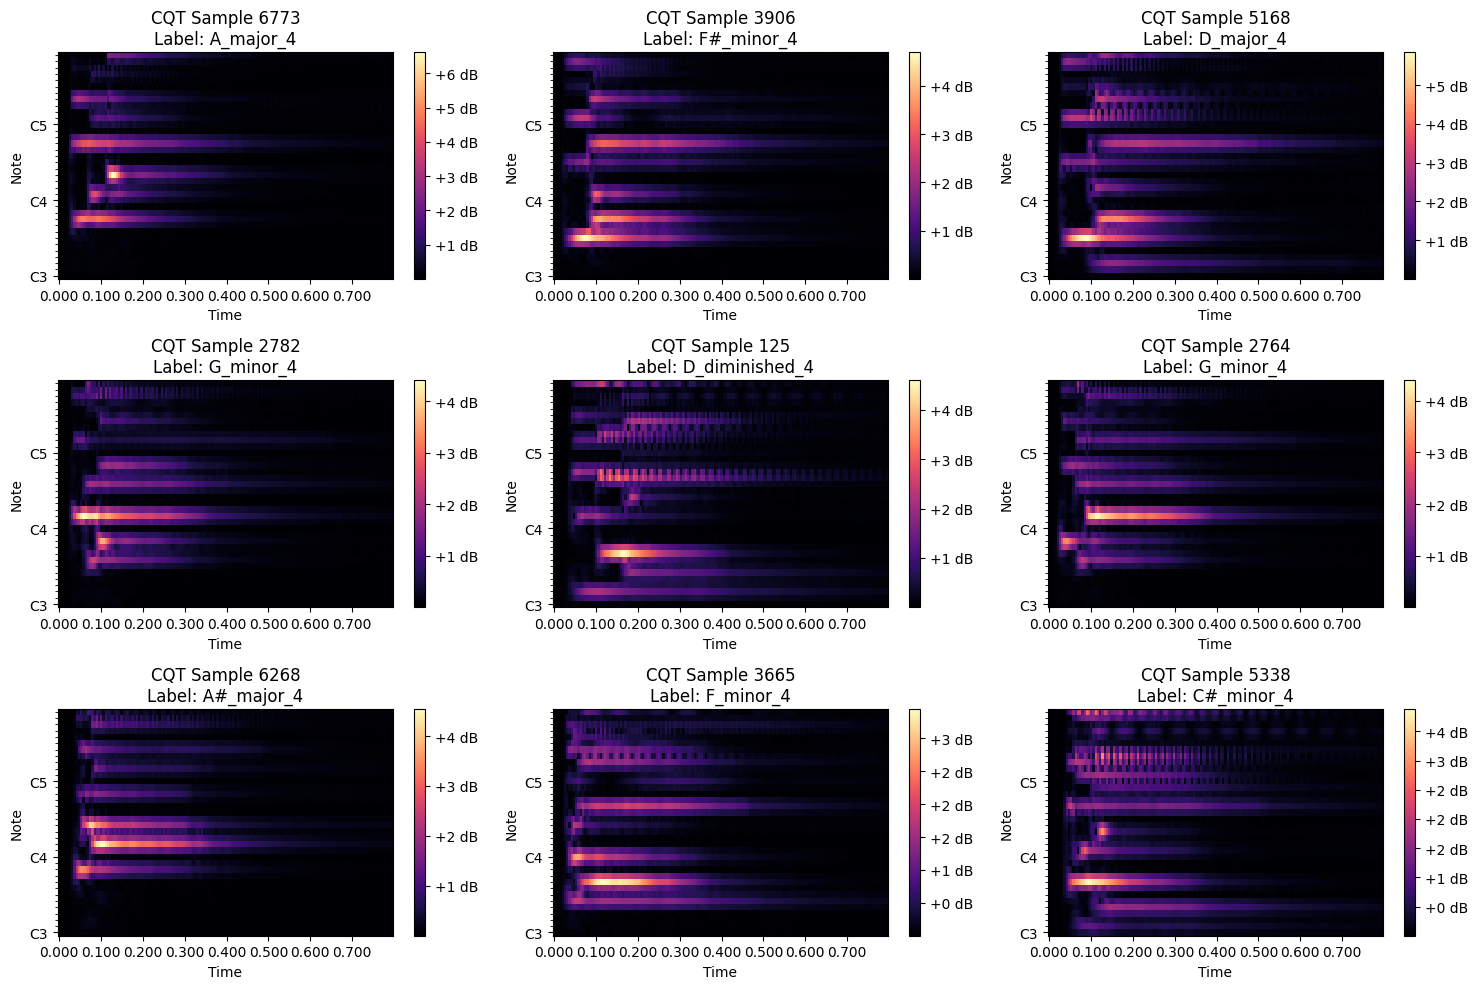

In [5]:
import random
import matplotlib.pyplot as plt
import librosa.display

# Select 9 random indices
random_indices = random.sample(range(len(features)), min(9, len(features)))
sr = 48_000

# Plot the CQT data for the selected samples
plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 1)
    # Assuming 'sr' is still available from the previous processing step
    try:
        # Explicitly pass fmin to specshow
        librosa.display.specshow(features[idx], x_axis='time', y_axis='cqt_note', sr=sr, bins_per_octave=12, fmin=fmin, hop_length=hop_length/2)
    except NameError:
        # Handle case where sr is not defined (e.g., if the previous cell failed)
        librosa.display.specshow(features[idx], x_axis='time', y_axis='cqt_note', bins_per_octave=12, fmin=fmin, hop_length=hop_length/2) # Plot without sr

    plt.colorbar(format='%+2.0f dB')
    plt.title(f'CQT Sample {idx+1}\nLabel: {labels[idx]}')

plt.tight_layout()
plt.show()

### Feature as data frame

Label: A_diminished_4
Shape: (36, 150)
Data type: float32
Min value: 0.0000
Max value: 4.6656


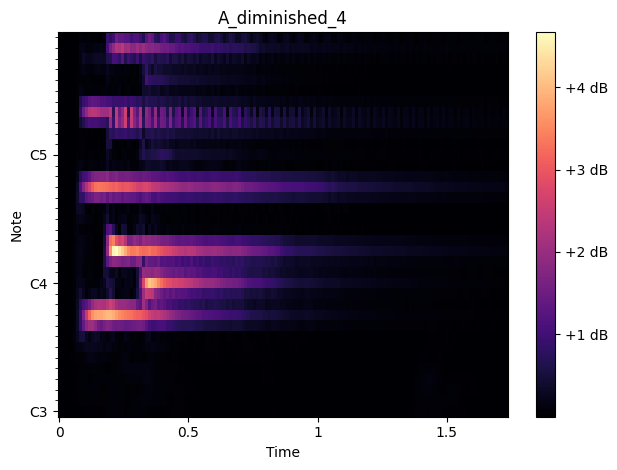

,Frame_1,Frame_2,Frame_3,Frame_4,Frame_5,Frame_6,Frame_7,Frame_8,Frame_9,Frame_10,...,Frame_141,Frame_142,Frame_143,Frame_144,Frame_145,Frame_146,Frame_147,Frame_148,Frame_149,Frame_150
C3,0.000220,0.000507,0.002389,0.007072,0.012265,0.016163,0.015213,0.007293,0.008193,0.020469,...,0.007705,0.011261,0.014034,0.015706,0.016462,0.016517,0.016439,0.016109,0.014750,0.012441
C♯3,0.000061,0.000208,0.001509,0.005763,0.013611,0.022657,0.030144,0.037516,0.048071,0.056773,...,0.012566,0.012353,0.010806,0.007407,0.005267,0.006949,0.009047,0.009525,0.008181,0.005414
D3,0.000188,0.001353,0.001091,0.004058,0.011567,0.025396,0.041888,0.057562,0.070299,0.078090,...,0.014886,0.009763,0.005891,0.004796,0.004956,0.005073,0.005334,0.005523,0.005184,0.004753
D♯3,0.000711,0.001013,0.001876,0.005021,0.012424,0.025331,0.045832,0.060840,0.057631,0.040914,...,0.006902,0.002998,0.003015,0.001592,0.002070,0.005345,0.007143,0.006884,0.005290,0.003882
E3,0.000641,0.001085,0.001114,0.004645,0.017209,0.027048,0.027627,0.037181,0.057547,0.070597,...,0.009455,0.005844,0.005074,0.005892,0.006472,0.006855,0.007580,0.008471,0.009007,0.008949
F3,0.000585,0.001677,0.002664,0.005565,0.021036,0.039904,0.050728,0.049085,0.074902,0.131426,...,0.009047,0.005374,0.002847,0.002199,0.004067,0.004811,0.003136,0.001106,0.004979,0.007824
F♯3,0.000232,0.001251,0.001568,0.000722,0.017471,0.082969,0.146238,0.160117,0.205563,0.269049,...,0.003112,0.004873,0.003923,0.003162,0.001233,0.001547,0.003528,0.005548,0.008108,0.009334
G3,0.000375,0.000873,0.001953,0.004323,0.007400,0.093388,0.285656,0.488079,0.505779,0.290424,...,0.007321,0.009477,0.010431,0.008686,0.007074,0.007013,0.007745,0.006504,0.002736,0.005311
G♯3,0.000343,0.000444,0.001177,0.000749,0.002795,0.080643,0.349667,0.827403,1.367868,1.799417,...,0.020160,0.011262,0.005178,0.014275,0.019670,0.018407,0.011576,0.006566,0.007717,0.010512
A3,0.000232,0.000359,0.000658,0.001247,0.004214,0.067049,0.351046,0.911911,1.674788,2.488192,...,0.029145,0.024490,0.023713,0.026631,0.027072,0.026006,0.021336,0.020551,0.021408,0.025458


In [6]:
import pandas as pd

# 1. Grab sample feature and label
sample_idx = random.randint(0, len(features))
sample_feature = features[sample_idx] 
sample_label = labels[sample_idx]

print(f"Label: {sample_label}")
print(f"Shape: {sample_feature.shape}")
print(f"Data type: {sample_feature.dtype}")
print(f"Min value: {np.min(sample_feature):.4f}")
print(f"Max value: {np.max(sample_feature):.4f}")

# 2. Generate the exact frequencies for your 36 bins
# Make sure 'fmin' matches the variable you used when creating the CQT!
frequencies = librosa.cqt_frequencies(
    n_bins=sample_feature.shape[0], 
    fmin=fmin, 
    bins_per_octave=12 
)

# 3. Convert those frequencies to musical note names (e.g., 'C4', 'D#4')
note_headers = librosa.hz_to_note(frequencies)

# 4. Create column headers for the time frames
column_headers = [f"Frame_{i+1}" for i in range(sample_feature.shape[1])]

# 3. Convert the 2D numpy array into a Pandas DataFrame
df = pd.DataFrame(sample_feature, columns=column_headers, index=note_headers)

librosa.display.specshow(sample_feature, x_axis='time', y_axis='cqt_note', bins_per_octave=12, fmin=fmin, hop_length=hop_length/2)
plt.colorbar(format='%+2.0f dB')
plt.title(sample_label)
plt.tight_layout()
plt.show()

df

## Save features as CSV (TODO)

# CNN model

## Define constants

In [7]:
%%skip_if SKIP_CNN_TRAINING

CNN_RANDOM_STATE = RANDOM_STATE
CNN_VALIDATION_SPLIT = 0.1
CNN_TEST_SIZE = 0.1
CNN_EPOCHS = 30
CNN_BATCH_SIZE = 32

set_random_seed(CNN_RANDOM_STATE)

## Single model

### Split data


In [8]:
%%skip_if SKIP_CNN_TRAINING

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
categorical_labels = to_categorical(encoded_labels)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    features,
    categorical_labels,
    test_size=CNN_TEST_SIZE,
    random_state=CNN_RANDOM_STATE,
    stratify=categorical_labels
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"Length of training set: {len(X_train)}")
print(f"Length of testing set: {len(X_test)}")

Shape of X_train: (6480, 36, 150)
Shape of X_test: (720, 36, 150)
Shape of y_train: (6480, 36)
Shape of y_test: (720, 36)
Length of training set: 6480
Length of testing set: 720


### Build model


In [9]:
%%skip_if SKIP_CNN_TRAINING

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Get input shape and number of classes
input_shape = (features.shape[1], features.shape[2], 1) # Add channel dimension based on original features shape
num_classes = y_train.shape[1]

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 34, 148, 32)       320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 17, 74, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 15, 72, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 7, 36, 64)         0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 16128)             0         
                                                                 
 dense (Dense)               (None, 64)                1

### Train model

In [10]:
%%skip_if SKIP_CNN_TRAINING

# Train the model
history = model.fit(X_train, y_train, epochs=CNN_EPOCHS, batch_size=CNN_BATCH_SIZE, validation_split=CNN_VALIDATION_SPLIT)

Epoch 1/30


I0000 00:00:1772899041.988817  438503 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


183/183 [==============================] - 5s 10ms/step - loss: 1.3367 - accuracy: 0.6024 - val_loss: 0.0110 - val_accuracy: 1.0000
Epoch 2/30
183/183 [==============================] - 1s 7ms/step - loss: 0.3670 - accuracy: 0.8668 - val_loss: 0.0015 - val_accuracy: 1.0000
Epoch 3/30
183/183 [==============================] - 1s 7ms/step - loss: 0.2728 - accuracy: 0.9002 - val_loss: 5.1486e-04 - val_accuracy: 1.0000
Epoch 4/30
183/183 [==============================] - 1s 7ms/step - loss: 0.2166 - accuracy: 0.9177 - val_loss: 1.2267e-04 - val_accuracy: 1.0000
Epoch 5/30
183/183 [==============================] - 1s 7ms/step - loss: 0.2094 - accuracy: 0.9204 - val_loss: 4.1840e-05 - val_accuracy: 1.0000
Epoch 6/30
183/183 [==============================] - 1s 7ms/step - loss: 0.1861 - accuracy: 0.9287 - val_loss: 1.9976e-05 - val_accuracy: 1.0000
Epoch 7/30
183/183 [==============================] - 1s 7ms/step - loss: 0.1647 - accuracy: 0.9372 - val_loss: 1.0995e-05 - val_accuracy: 1.0

### Class distribution

In [11]:
%%skip_if SKIP_CNN_TRAINING

from collections import Counter
import numpy as np

import matplotlib.pyplot as plt

# Keras validation_split takes the last fraction of training data
val_size = int(len(y_train) * CNN_VALIDATION_SPLIT)
y_train_actual = y_train[:-val_size]
y_val          = y_train[-val_size:]

# Get class distribution for train, validation, and test sets
train_dist = Counter(np.argmax(y_train_actual, axis=1))
val_dist   = Counter(np.argmax(y_val,          axis=1))
test_dist  = Counter(np.argmax(y_test,         axis=1))

class_names = label_encoder.classes_
x = np.arange(len(class_names))
width = 0.4

train_counts = [train_dist.get(i, 0) for i in range(len(class_names))]
val_counts   = [val_dist.get(i, 0)   for i in range(len(class_names))]
test_counts  = [test_dist.get(i, 0)  for i in range(len(class_names))]

# Print summary table
print(f"\n{'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print("-" * 56)
for i, name in enumerate(class_names):
  tr = train_dist.get(i, 0)
  vl = val_dist.get(i, 0)
  te = test_dist.get(i, 0)
  print(f"{name:<20} {tr:>8} {vl:>8} {te:>8} {tr+vl+te:>8}")
print("-" * 56)
print(f"{'TOTAL':<20} {sum(train_counts):>8} {sum(val_counts):>8} {sum(test_counts):>8} {sum(train_counts)+sum(val_counts)+sum(test_counts):>8}")



Class                   Train      Val     Test    Total
--------------------------------------------------------
A#_diminished_4           166       14       20      200
A#_major_4                167       13       20      200
A#_minor_4                162       18       20      200
A_diminished_4            166       14       20      200
A_major_4                 155       25       20      200
A_minor_4                 160       20       20      200
B_diminished_4            160       20       20      200
B_major_4                 162       18       20      200
B_minor_4                 164       16       20      200
C#_diminished_4           165       15       20      200
C#_major_4                168       12       20      200
C#_minor_4                166       14       20      200
C_diminished_4            157       23       20      200
C_major_4                 156       24       20      200
C_minor_4                 158       22       20      200
D#_diminished_4           162 

### Training history

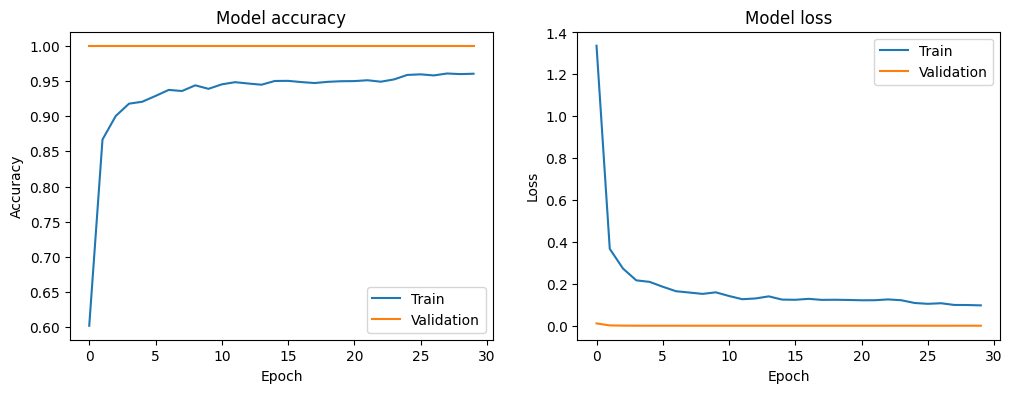

In [12]:
%%skip_if SKIP_CNN_TRAINING

import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.show()

### Confusion Matrix

23/23 [==============================] - 0s 3ms/step


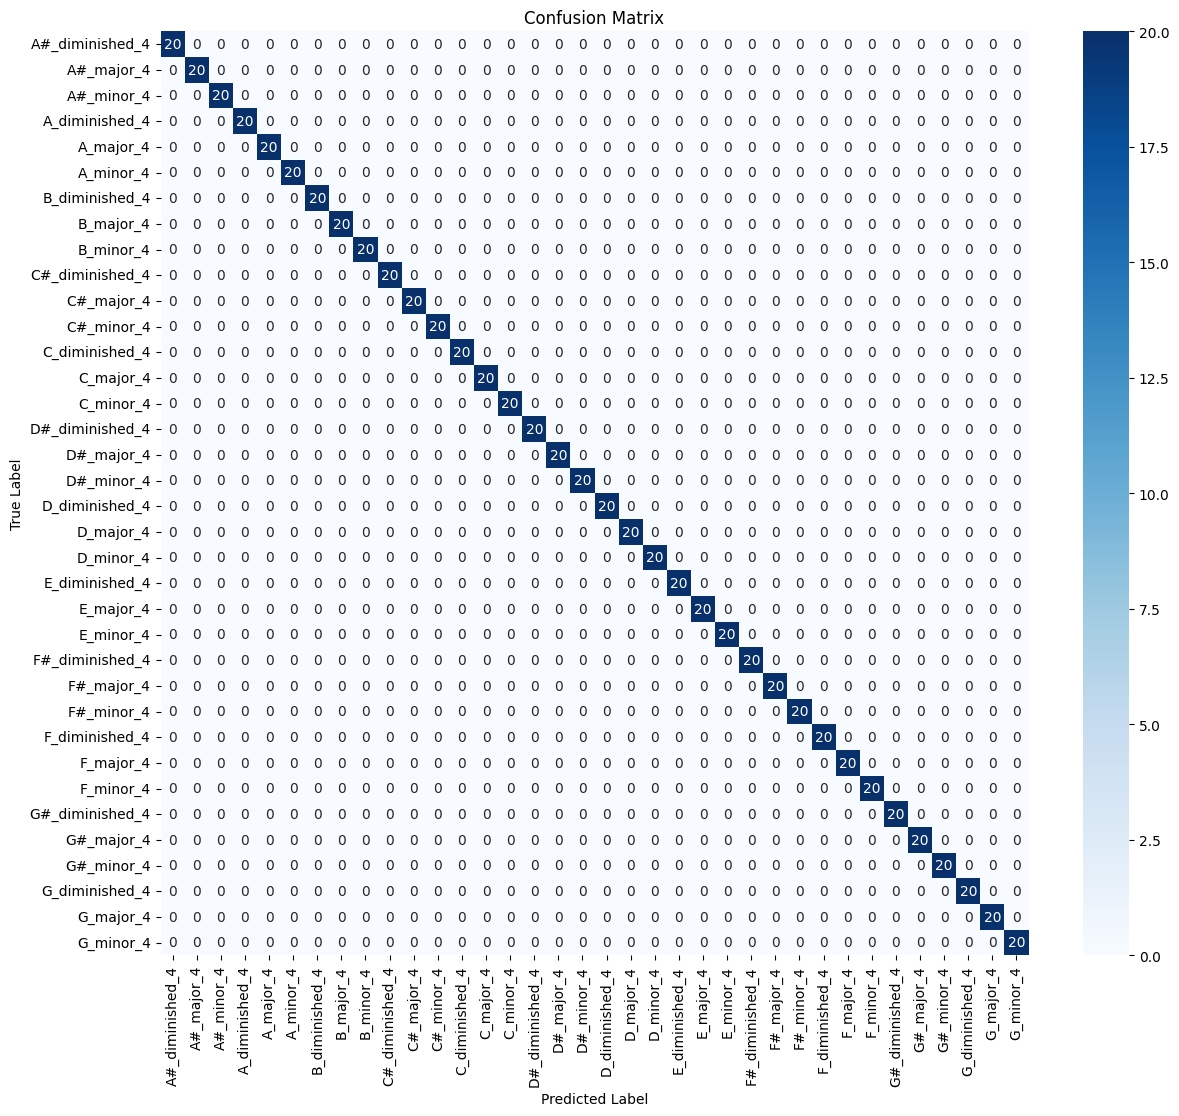

In [13]:
%%skip_if SKIP_CNN_TRAINING

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predictions for the test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Get class labels from the label encoder
class_labels = label_encoder.classes_

# Compute the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [14]:
%%skip_if SKIP_CNN_TRAINING

from sklearn.metrics import classification_report

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy}")
print(f"Test Loss: {loss}")

# Generate classification report
report = classification_report(y_true_classes, y_pred_classes, target_names=class_labels)
print("Classification Report:\n", report)

Test Accuracy: 1.0
Test Loss: 1.904036572852874e-08
Classification Report:
                  precision    recall  f1-score   support

A#_diminished_4       1.00      1.00      1.00        20
     A#_major_4       1.00      1.00      1.00        20
     A#_minor_4       1.00      1.00      1.00        20
 A_diminished_4       1.00      1.00      1.00        20
      A_major_4       1.00      1.00      1.00        20
      A_minor_4       1.00      1.00      1.00        20
 B_diminished_4       1.00      1.00      1.00        20
      B_major_4       1.00      1.00      1.00        20
      B_minor_4       1.00      1.00      1.00        20
C#_diminished_4       1.00      1.00      1.00        20
     C#_major_4       1.00      1.00      1.00        20
     C#_minor_4       1.00      1.00      1.00        20
 C_diminished_4       1.00      1.00      1.00        20
      C_major_4       1.00      1.00      1.00        20
      C_minor_4       1.00      1.00      1.00        20
D#_diminish

### Save Model

In [15]:
%%skip_if SKIP_CNN_TRAINING

# Save the model
model.save(cnn_model_path_clean + '.h5')
print(f"Model saved to {cnn_model_path_clean}.h5")

Model saved to ./models-150/cnn_model-clean.h5


### Test Model

In [16]:
%%skip_if SKIP_CNN_TRAINING

import tensorflow as tf
import numpy as np

# Load the saved Keras model
clean_loaded_model = tf.keras.models.load_model(cnn_model_path_clean + '.h5')

# Select a fixed (seeded) sample from the test set
rng = np.random.default_rng(CNN_RANDOM_STATE)
random_index = int(rng.integers(0, len(X_test)))
sample_features = X_test[random_index]
sample_actual_label_categorical = y_test[random_index]

# Reshape the sample features for prediction (add batch and channel dimensions)
sample_features_reshaped = np.expand_dims(sample_features, axis=0)
sample_features_reshaped = np.expand_dims(sample_features_reshaped, axis=-1)

# Make a prediction
predictions = clean_loaded_model.predict(sample_features_reshaped)
predicted_class_index = np.argmax(predictions)

# Decode the actual and predicted labels
actual_class_index = np.argmax(sample_actual_label_categorical)
actual_class_label = label_encoder.inverse_transform([actual_class_index])[0]
predicted_class_label = label_encoder.inverse_transform([predicted_class_index])[0]

print(f"Actual Label: {actual_class_label}")
print(f"Predicted Label: {predicted_class_label}")


1/1 [==============================] - 0s 117ms/step
Actual Label: E_major_4
Predicted Label: E_major_4


### Convert model to tfjs

In [17]:
%%skip_if SKIP_CNN_TRAINING

!TF_DETERMINISTIC_OPS=0 tensorflowjs_converter --input_format=keras --output_format=tfjs_graph_model {cnn_model_path_clean}.h5 {cnn_model_path_clean} && echo TensorFlow.js model saved to {cnn_model_path_clean}

/home/seya/code/chord-detection/training/.venv/lib/python3.10/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
TensorFlow.js model saved to ./models-150/cnn_model-clean


## K-Fold cross-validation

### Define constants

In [18]:
%%skip_if SKIP_CNN_TRAINING or SKIP_CNN_KFOLD

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

KFOLD_N_SPLITS = 5
KFOLD_RANDOM_STATE = CNN_RANDOM_STATE
KFOLD_VALIDATION_SPLIT = CNN_VALIDATION_SPLIT
KFOLD_TEST_SIZE = CNN_TEST_SIZE
KFOLD_EPOCHS = CNN_EPOCHS
KFOLD_BATCH_SIZE = CNN_BATCH_SIZE

set_random_seed(KFOLD_RANDOM_STATE)

def create_cnn_model(input_shape, num_classes):
    """Defines and compiles the CNN model architecture."""
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
categorical_labels = to_categorical(encoded_labels)

input_shape = (features.shape[1], features.shape[2], 1)
num_classes = categorical_labels.shape[1]

Skipped cell because SKIP_CNN_TRAINING or SKIP_CNN_KFOLD


### Train

In [19]:
%%skip_if SKIP_CNN_TRAINING or SKIP_CNN_KFOLD

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import tensorflow as tf

# Instantiate KFold
kf = KFold(n_splits=KFOLD_N_SPLITS, shuffle=True, random_state=KFOLD_RANDOM_STATE)

# Initialize lists to store performance metrics for each fold
fold_accuracies = []
fold_losses = []
fold_histories = []
fold_confusion_matrices = []

for fold, (train_val_index, test_index) in enumerate(kf.split(features, encoded_labels)):
    print(f"\n--- Fold {fold+1}/{kf.n_splits} ---")

    # Set per-fold seed so each fold is independently reproducible
    tf.random.set_seed(KFOLD_RANDOM_STATE + fold)
    np.random.seed(KFOLD_RANDOM_STATE + fold)

    # Split train_val_index
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=KFOLD_TEST_SIZE,
        random_state=KFOLD_RANDOM_STATE,
        stratify=encoded_labels[train_val_index]  # preserve class distribution
    )

    X_train_fold = np.expand_dims(features[train_index], axis=-1)
    X_val_fold   = np.expand_dims(features[val_index],   axis=-1)
    X_test_fold  = np.expand_dims(features[test_index],  axis=-1)

    y_train_fold = categorical_labels[train_index]
    y_val_fold   = categorical_labels[val_index]
    y_test_fold  = categorical_labels[test_index]

    model = create_cnn_model(input_shape, num_classes)

    print(f"Training model for Fold {fold+1}...")
    history = model.fit(
        X_train_fold, y_train_fold,
        epochs=KFOLD_EPOCHS,
        batch_size=KFOLD_BATCH_SIZE,
        validation_data=(X_val_fold, y_val_fold),  # enables val metrics per epoch
        validation_split=KFOLD_VALIDATION_SPLIT,
        verbose=0
    )
    fold_histories.append(history)

    print(f"Evaluating model for Fold {fold+1}...")
    loss, accuracy = model.evaluate(X_test_fold, y_test_fold, verbose=0)

    y_pred_fold = model.predict(X_test_fold, verbose=0)
    y_pred_classes = np.argmax(y_pred_fold, axis=1)
    y_true_classes = np.argmax(y_test_fold, axis=1)
    fold_confusion_matrices.append(confusion_matrix(y_true_classes, y_pred_classes))

    fold_accuracies.append(accuracy)
    fold_losses.append(loss)
    print(f"Fold {fold+1} - Test Accuracy: {accuracy:.4f}, Test Loss: {loss:.4f}")

print("\nK-Fold Cross-Validation complete.")


Skipped cell because SKIP_CNN_TRAINING or SKIP_CNN_KFOLD


### Show class distribution

In [20]:
%%skip_if SKIP_CNN_TRAINING or SKIP_CNN_KFOLD

from collections import Counter
import numpy as np

print("=" * 65)
print("              Class Distribution per Fold")
print("=" * 65)

for fold, (train_val_index, test_index) in enumerate(kf.split(features, encoded_labels)):
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=KFOLD_TEST_SIZE,
        random_state=KFOLD_RANDOM_STATE,
        stratify=encoded_labels[train_val_index]
    )

    train_dist = Counter(encoded_labels[train_index])
    val_dist   = Counter(encoded_labels[val_index])
    test_dist  = Counter(encoded_labels[test_index])

    classes = sorted(train_dist.keys())
    class_names = label_encoder.inverse_transform(classes)

    print(f"\n  Fold {fold+1}")
    print(f"  {'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8}  {'Total':>8}")
    print(f"  {'-'*20} {'-'*8} {'-'*8} {'-'*8}  {'-'*8}")

    for cls, name in zip(classes, class_names):
        tr = train_dist.get(cls, 0)
        vl = val_dist.get(cls, 0)
        te = test_dist.get(cls, 0)
        print(f"  {str(name):<20} {tr:>8} {vl:>8} {te:>8}  {tr+vl+te:>8}")

    print(f"  {'TOTAL':<20} {sum(train_dist.values()):>8} {sum(val_dist.values()):>8} {sum(test_dist.values()):>8}  {len(encoded_labels):>8}")

print("\n" + "=" * 65)

Skipped cell because SKIP_CNN_TRAINING or SKIP_CNN_KFOLD


### Confusion Matrix per Fold

In [21]:
%%skip_if SKIP_CNN_TRAINING or SKIP_CNN_KFOLD

import matplotlib.pyplot as plt
import seaborn as sns

class_labels = label_encoder.classes_

for i, cm in enumerate(fold_confusion_matrices):
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Fold {i+1} Confusion Matrix')
    plt.tight_layout()
    plt.show()

Skipped cell because SKIP_CNN_TRAINING or SKIP_CNN_KFOLD


### Accuracy & Loss Plot

In [22]:
%%skip_if SKIP_CNN_TRAINING or SKIP_CNN_KFOLD

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 6))

# --- Accuracy ---
plt.subplot(1, 2, 1)
for i, history_obj in enumerate(fold_histories):
    plt.plot(history_obj.history['accuracy'],
             label=f'Fold {i+1} Train Acc')
    plt.plot(history_obj.history['val_accuracy'],
             linestyle='--', label=f'Fold {i+1} Val Acc')

plt.title('Training & Validation Accuracy per Fold')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right', bbox_to_anchor=(1.05, 0), fontsize='small')
plt.grid(True)

# --- Loss ---
plt.subplot(1, 2, 2)
for i, history_obj in enumerate(fold_histories):
    plt.plot(history_obj.history['loss'],
             label=f'Fold {i+1} Train Loss')
    plt.plot(history_obj.history['val_loss'],
             linestyle='--', label=f'Fold {i+1} Val Loss')

plt.title('Training & Validation Loss per Fold')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right', bbox_to_anchor=(1.05, 1), fontsize='small')
plt.grid(True)

plt.tight_layout()
plt.show()

Skipped cell because SKIP_CNN_TRAINING or SKIP_CNN_KFOLD


### Mean & Std Deviation

In [23]:
%%skip_if SKIP_CNN_TRAINING or SKIP_CNN_KFOLD

import numpy as np

# Collect final-epoch train/val metrics from each fold's history
train_accs = [h.history['accuracy'][-1]     for h in fold_histories]
val_accs   = [h.history['val_accuracy'][-1] for h in fold_histories]
train_losses = [h.history['loss'][-1]       for h in fold_histories]
val_losses   = [h.history['val_loss'][-1]   for h in fold_histories]

print("=" * 73)
print("         Stratified K-Fold Cross-Validation Summary (per fold)")
print("=" * 73)
print(f"  {'':>6}  {'Train Acc':>10}  {'Val Acc':>10}  {'Test Acc':>10}  {'Train Loss':>11}  {'Val Loss':>10}  {'Test Loss':>10}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")
for i in range(len(fold_accuracies)):
    print(f"  Fold {i+1:>1}  {train_accs[i]:>10.4f}  {val_accs[i]:>10.4f}  {fold_accuracies[i]:>10.4f}  {train_losses[i]:>11.4f}  {val_losses[i]:>10.4f}  {fold_losses[i]:>10.4f}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")
print(f"  {'Mean':>6}  {np.mean(train_accs):>10.4f}  {np.mean(val_accs):>10.4f}  {np.mean(fold_accuracies):>10.4f}  {np.mean(train_losses):>11.4f}  {np.mean(val_losses):>10.4f}  {np.mean(fold_losses):>10.4f}")
print(f"  {'Std':>6}  {np.std(train_accs):>10.4f}  {np.std(val_accs):>10.4f}  {np.std(fold_accuracies):>10.4f}  {np.std(train_losses):>11.4f}  {np.std(val_losses):>10.4f}  {np.std(fold_losses):>10.4f}")
print("=" * 73)

Skipped cell because SKIP_CNN_TRAINING or SKIP_CNN_KFOLD


## Stratified K-Fold

In [24]:
%%skip_if SKIP_CNN_TRAINING or SKIP_CNN_KFOLD

SKFOLD_N_SPLITS = KFOLD_N_SPLITS
SKFOLD_RANDOM_STATE = CNN_RANDOM_STATE
SKFOLD_VALIDATION_SPLIT = CNN_VALIDATION_SPLIT
SKFOLD_TEST_SIZE = CNN_TEST_SIZE
SKFOLD_EPOCHS = CNN_EPOCHS
SKFOLD_BATCH_SIZE = CNN_BATCH_SIZE

set_random_seed(SKFOLD_RANDOM_STATE)

Skipped cell because SKIP_CNN_TRAINING or SKIP_CNN_KFOLD


### Train

In [25]:
%%skip_if SKIP_CNN_TRAINING or SKIP_CNN_KFOLD

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import tensorflow as tf

# Instantiate KFold
skf = StratifiedKFold(n_splits=SKFOLD_N_SPLITS, shuffle=True, random_state=SKFOLD_RANDOM_STATE)

# Initialize lists to store performance metrics for each fold
sfold_accuracies = []
sfold_losses = []
sfold_histories = []
sfold_confusion_matrices = []

for fold, (train_val_index, test_index) in enumerate(skf.split(features, encoded_labels)):
    print(f"\n--- Fold {fold+1}/{skf.n_splits} ---")

    # Set per-fold seed so each fold is independently reproducible
    tf.random.set_seed(SKFOLD_RANDOM_STATE + fold)
    np.random.seed(SKFOLD_RANDOM_STATE + fold)

    # Split train_val_index
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=SKFOLD_TEST_SIZE,
        random_state=SKFOLD_RANDOM_STATE,
        stratify=encoded_labels[train_val_index]  # preserve class distribution
    )

    X_train_fold = np.expand_dims(features[train_index], axis=-1)
    X_val_fold   = np.expand_dims(features[val_index],   axis=-1)
    X_test_fold  = np.expand_dims(features[test_index],  axis=-1)

    y_train_fold = categorical_labels[train_index]
    y_val_fold   = categorical_labels[val_index]
    y_test_fold  = categorical_labels[test_index]

    model = create_cnn_model(input_shape, num_classes)

    print(f"Training model for Fold {fold+1}...")
    history = model.fit(
        X_train_fold, y_train_fold,
        epochs=SKFOLD_EPOCHS,
        batch_size=SKFOLD_BATCH_SIZE,
        validation_data=(X_val_fold, y_val_fold),  # enables val metrics per epoch
        validation_split=SKFOLD_VALIDATION_SPLIT,
        verbose=0
    )
    sfold_histories.append(history)

    print(f"Evaluating model for Fold {fold+1}...")
    loss, accuracy = model.evaluate(X_test_fold, y_test_fold, verbose=0)

    y_pred_fold = model.predict(X_test_fold, verbose=0)
    y_pred_classes = np.argmax(y_pred_fold, axis=1)
    y_true_classes = np.argmax(y_test_fold, axis=1)
    sfold_confusion_matrices.append(confusion_matrix(y_true_classes, y_pred_classes))

    sfold_accuracies.append(accuracy)
    sfold_losses.append(loss)
    print(f"Fold {fold+1} - Test Accuracy: {accuracy:.4f}, Test Loss: {loss:.4f}")

print("\nStratified K-Fold Cross-Validation complete.")


Skipped cell because SKIP_CNN_TRAINING or SKIP_CNN_KFOLD


### Show class distribution

In [26]:
%%skip_if SKIP_CNN_TRAINING or SKIP_CNN_KFOLD

from collections import Counter
import numpy as np

print("=" * 65)
print("              Class Distribution per Fold")
print("=" * 65)

for fold, (train_val_index, test_index) in enumerate(skf.split(features, encoded_labels)):
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=SKFOLD_TEST_SIZE,
        random_state=SKFOLD_RANDOM_STATE,
        stratify=encoded_labels[train_val_index]
    )

    train_dist = Counter(encoded_labels[train_index])
    val_dist   = Counter(encoded_labels[val_index])
    test_dist  = Counter(encoded_labels[test_index])

    classes = sorted(train_dist.keys())
    class_names = label_encoder.inverse_transform(classes)

    print(f"\n  Fold {fold+1}")
    print(f"  {'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8}  {'Total':>8}")
    print(f"  {'-'*20} {'-'*8} {'-'*8} {'-'*8}  {'-'*8}")

    for cls, name in zip(classes, class_names):
        tr = train_dist.get(cls, 0)
        vl = val_dist.get(cls, 0)
        te = test_dist.get(cls, 0)
        print(f"  {str(name):<20} {tr:>8} {vl:>8} {te:>8}  {tr+vl+te:>8}")

    print(f"  {'TOTAL':<20} {sum(train_dist.values()):>8} {sum(val_dist.values()):>8} {sum(test_dist.values()):>8}  {len(encoded_labels):>8}")

print("\n" + "=" * 65)

Skipped cell because SKIP_CNN_TRAINING or SKIP_CNN_KFOLD


### Confusion Matrix per Fold

In [27]:
%%skip_if SKIP_CNN_TRAINING or SKIP_CNN_KFOLD

import matplotlib.pyplot as plt
import seaborn as sns

class_labels = label_encoder.classes_

for i, cm in enumerate(sfold_confusion_matrices):
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Fold {i+1} Confusion Matrix')
    plt.tight_layout()
    plt.show()

Skipped cell because SKIP_CNN_TRAINING or SKIP_CNN_KFOLD


### Accuracy & Loss Plot

In [28]:
%%skip_if SKIP_CNN_TRAINING or SKIP_CNN_KFOLD

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 6))

# --- Accuracy ---
plt.subplot(1, 2, 1)
for i, history_obj in enumerate(sfold_histories):
    plt.plot(history_obj.history['accuracy'],
             label=f'Fold {i+1} Train Acc')
    plt.plot(history_obj.history['val_accuracy'],
             linestyle='--', label=f'Fold {i+1} Val Acc')

plt.title('Training & Validation Accuracy per Fold')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right', bbox_to_anchor=(1.05, 0), fontsize='small')
plt.grid(True)

# --- Loss ---
plt.subplot(1, 2, 2)
for i, history_obj in enumerate(sfold_histories):
    plt.plot(history_obj.history['loss'],
             label=f'Fold {i+1} Train Loss')
    plt.plot(history_obj.history['val_loss'],
             linestyle='--', label=f'Fold {i+1} Val Loss')

plt.title('Training & Validation Loss per Fold')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right', bbox_to_anchor=(1.05, 1), fontsize='small')
plt.grid(True)

plt.tight_layout()
plt.show()

Skipped cell because SKIP_CNN_TRAINING or SKIP_CNN_KFOLD


### Mean & Std Deviation

In [29]:
%%skip_if SKIP_CNN_TRAINING or SKIP_CNN_KFOLD

import numpy as np

# Collect final-epoch train/val metrics from each fold's history
train_accs = [h.history['accuracy'][-1]     for h in sfold_histories]
val_accs   = [h.history['val_accuracy'][-1] for h in sfold_histories]
train_losses = [h.history['loss'][-1]       for h in sfold_histories]
val_losses   = [h.history['val_loss'][-1]   for h in sfold_histories]

print("=" * 73)
print("         Stratified K-Fold Cross-Validation Summary (per fold)")
print("=" * 73)
print(f"  {'':>6}  {'Train Acc':>10}  {'Val Acc':>10}  {'Test Acc':>10}  {'Train Loss':>11}  {'Val Loss':>10}  {'Test Loss':>10}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")
for i in range(len(sfold_accuracies)):
    print(f"  Fold {i+1:>1}  {train_accs[i]:>10.4f}  {val_accs[i]:>10.4f}  {sfold_accuracies[i]:>10.4f}  {train_losses[i]:>11.4f}  {val_losses[i]:>10.4f}  {sfold_losses[i]:>10.4f}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")
print(f"  {'Mean':>6}  {np.mean(train_accs):>10.4f}  {np.mean(val_accs):>10.4f}  {np.mean(sfold_accuracies):>10.4f}  {np.mean(train_losses):>11.4f}  {np.mean(val_losses):>10.4f}  {np.mean(sfold_losses):>10.4f}")
print(f"  {'Std':>6}  {np.std(train_accs):>10.4f}  {np.std(val_accs):>10.4f}  {np.std(sfold_accuracies):>10.4f}  {np.std(train_losses):>11.4f}  {np.std(val_losses):>10.4f}  {np.std(sfold_losses):>10.4f}")
print("=" * 73)

Skipped cell because SKIP_CNN_TRAINING or SKIP_CNN_KFOLD


# SVM model

## Define constants

In [30]:
%%skip_if SKIP_SVM_TRAINING

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

SVM_RANDOM_STATE = RANDOM_STATE
SVM_TEST_SIZE = 0.1
SVM_CV_FOLDS = 5

set_random_seed(SVM_RANDOM_STATE)

# Flatten 2D CQT features to 1D for SVM input
features_flat = features.reshape(features.shape[0], -1)

# Encode labels
svm_label_encoder = LabelEncoder()
svm_encoded_labels = svm_label_encoder.fit_transform(labels)

# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_flat)

# Train/test split
X_svm_train, X_svm_test, y_svm_train, y_svm_test = train_test_split(
    features_scaled,
    svm_encoded_labels,
    test_size=SVM_TEST_SIZE,
    random_state=SVM_RANDOM_STATE,
    stratify=svm_encoded_labels
)

print(f"X_svm_train shape: {X_svm_train.shape}")
print(f"X_svm_test shape:  {X_svm_test.shape}")
print(f"Number of classes: {len(svm_label_encoder.classes_)}")

X_svm_train shape: (6480, 5400)
X_svm_test shape:  (720, 5400)
Number of classes: 36


## Single model

### Train model

In [31]:
%%skip_if SKIP_SVM_TRAINING

from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=10, gamma='scale', random_state=SVM_RANDOM_STATE)

print("Training SVM model...")
svm_model.fit(X_svm_train, y_svm_train)
print("Training complete.")

Training SVM model...
Training complete.


### Evaluate model

In [32]:
%%skip_if SKIP_SVM_TRAINING

from sklearn.metrics import accuracy_score, classification_report

y_svm_pred = svm_model.predict(X_svm_test)

svm_accuracy = accuracy_score(y_svm_test, y_svm_pred)
print(f"Test Accuracy: {svm_accuracy:.4f}")

svm_class_labels = svm_label_encoder.classes_
report = classification_report(y_svm_test, y_svm_pred, target_names=svm_class_labels)
print("\nClassification Report:\n", report)

Test Accuracy: 1.0000

Classification Report:
                  precision    recall  f1-score   support

A#_diminished_4       1.00      1.00      1.00        20
     A#_major_4       1.00      1.00      1.00        20
     A#_minor_4       1.00      1.00      1.00        20
 A_diminished_4       1.00      1.00      1.00        20
      A_major_4       1.00      1.00      1.00        20
      A_minor_4       1.00      1.00      1.00        20
 B_diminished_4       1.00      1.00      1.00        20
      B_major_4       1.00      1.00      1.00        20
      B_minor_4       1.00      1.00      1.00        20
C#_diminished_4       1.00      1.00      1.00        20
     C#_major_4       1.00      1.00      1.00        20
     C#_minor_4       1.00      1.00      1.00        20
 C_diminished_4       1.00      1.00      1.00        20
      C_major_4       1.00      1.00      1.00        20
      C_minor_4       1.00      1.00      1.00        20
D#_diminished_4       1.00      1.00    

### Confusion Matrix

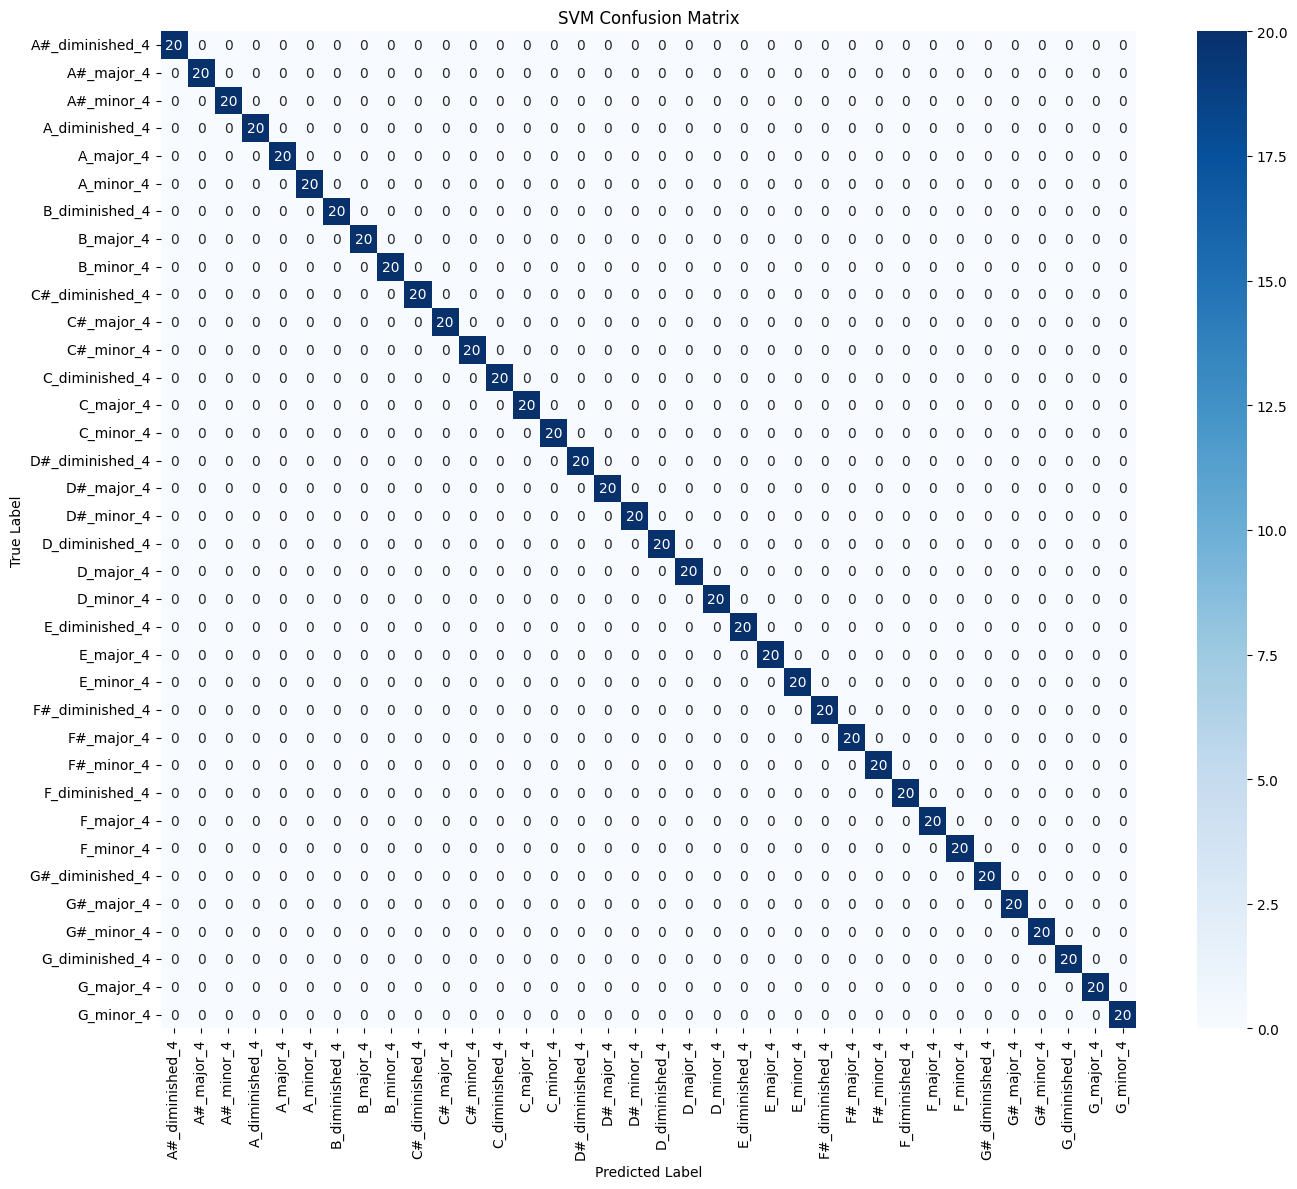

In [33]:
%%skip_if SKIP_SVM_TRAINING

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_svm_test, y_svm_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_class_labels, yticklabels=svm_class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix')
plt.tight_layout()
plt.show()

### Save SVM Model

In [34]:
%%skip_if SKIP_SVM_TRAINING

import joblib

joblib.dump(svm_model, svm_model_path)
joblib.dump(svm_label_encoder, svm_encoder_path)

print(f"SVM model saved to {svm_model_dir}")

SVM model saved to ./models-150/svm_model


## K-Fold cross-validation

### Define constants

In [35]:
%%skip_if SKIP_SVM_TRAINING or SKIP_SVM_KFOLD

import numpy as np
from sklearn.metrics import accuracy_score, hinge_loss
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

SVM_KFOLD_N_SPLITS = SVM_CV_FOLDS
SVM_KFOLD_RANDOM_STATE = SVM_RANDOM_STATE
SVM_KFOLD_VALIDATION_SIZE = 0.2

SVM_KFOLD_KERNEL = 'rbf'
SVM_KFOLD_C = 10
SVM_KFOLD_GAMMA = 'scale'

set_random_seed(SVM_KFOLD_RANDOM_STATE)

Skipped cell because SKIP_SVM_TRAINING or SKIP_SVM_KFOLD


### Train with K-Fold

In [36]:
%%skip_if SKIP_SVM_TRAINING or SKIP_SVM_KFOLD

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

svm_kf = KFold(
    n_splits=SVM_KFOLD_N_SPLITS,
    shuffle=True,
    random_state=SVM_KFOLD_RANDOM_STATE
)

svm_fold_train_accuracies = []
svm_fold_val_accuracies = []
svm_fold_test_accuracies = []

svm_fold_train_losses = []
svm_fold_val_losses = []
svm_fold_test_losses = []

svm_fold_confusion_matrices = []

svm_all_class_ids = np.arange(len(svm_label_encoder.classes_))

for fold, (train_val_index, test_index) in enumerate(svm_kf.split(features_flat, svm_encoded_labels)):
    print(f"\n--- Fold {fold+1}/{svm_kf.n_splits} ---")

    train_index, val_index = train_test_split(
        train_val_index,
        test_size=SVM_KFOLD_VALIDATION_SIZE,
        random_state=SVM_KFOLD_RANDOM_STATE,
        stratify=svm_encoded_labels[train_val_index]
    )

    X_train_fold_raw = features_flat[train_index]
    X_val_fold_raw   = features_flat[val_index]
    X_test_fold_raw  = features_flat[test_index]

    y_train_fold = svm_encoded_labels[train_index]
    y_val_fold   = svm_encoded_labels[val_index]
    y_test_fold  = svm_encoded_labels[test_index]

    fold_scaler = StandardScaler()
    X_train_fold = fold_scaler.fit_transform(X_train_fold_raw)
    X_val_fold   = fold_scaler.transform(X_val_fold_raw)
    X_test_fold  = fold_scaler.transform(X_test_fold_raw)

    svm_fold_model = SVC(
        kernel=SVM_KFOLD_KERNEL,
        C=SVM_KFOLD_C,
        gamma=SVM_KFOLD_GAMMA,
        decision_function_shape='ovr',
        random_state=SVM_KFOLD_RANDOM_STATE
    )

    print(f"Training SVM for Fold {fold+1}...")
    svm_fold_model.fit(X_train_fold, y_train_fold)

    train_pred = svm_fold_model.predict(X_train_fold)
    val_pred   = svm_fold_model.predict(X_val_fold)
    test_pred  = svm_fold_model.predict(X_test_fold)

    train_scores = svm_fold_model.decision_function(X_train_fold)
    val_scores   = svm_fold_model.decision_function(X_val_fold)
    test_scores  = svm_fold_model.decision_function(X_test_fold)

    train_accuracy = accuracy_score(y_train_fold, train_pred)
    val_accuracy   = accuracy_score(y_val_fold, val_pred)
    test_accuracy  = accuracy_score(y_test_fold, test_pred)

    train_loss = hinge_loss(y_train_fold, train_scores, labels=svm_all_class_ids)
    val_loss   = hinge_loss(y_val_fold, val_scores, labels=svm_all_class_ids)
    test_loss  = hinge_loss(y_test_fold, test_scores, labels=svm_all_class_ids)

    svm_fold_train_accuracies.append(train_accuracy)
    svm_fold_val_accuracies.append(val_accuracy)
    svm_fold_test_accuracies.append(test_accuracy)

    svm_fold_train_losses.append(train_loss)
    svm_fold_val_losses.append(val_loss)
    svm_fold_test_losses.append(test_loss)

    svm_fold_confusion_matrices.append(confusion_matrix(y_test_fold, test_pred))

    print(
        f"Fold {fold+1} - Train Accuracy: {train_accuracy:.4f}, "
        f"Val Accuracy: {val_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}"
    )
    print(
        f"Fold {fold+1} - Train Hinge Loss: {train_loss:.4f}, "
        f"Val Hinge Loss: {val_loss:.4f}, Test Hinge Loss: {test_loss:.4f}"
    )

print("\nSVM K-Fold Cross-Validation complete.")

Skipped cell because SKIP_SVM_TRAINING or SKIP_SVM_KFOLD


### Show class distribution

In [37]:
%%skip_if SKIP_SVM_TRAINING or SKIP_SVM_KFOLD

from collections import Counter
from sklearn.model_selection import train_test_split
import numpy as np

print("=" * 65)
print("              Class Distribution per Fold")
print("=" * 65)

class_ids = np.arange(len(svm_label_encoder.classes_))
class_names = svm_label_encoder.classes_

for fold, (train_val_index, test_index) in enumerate(svm_kf.split(features_flat, svm_encoded_labels)):
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=SVM_KFOLD_VALIDATION_SIZE,
        random_state=SVM_KFOLD_RANDOM_STATE,
        stratify=svm_encoded_labels[train_val_index]
    )

    train_dist = Counter(svm_encoded_labels[train_index])
    val_dist   = Counter(svm_encoded_labels[val_index])
    test_dist  = Counter(svm_encoded_labels[test_index])

    print(f"\n  Fold {fold+1}")
    print(f"  {'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8}  {'Total':>8}")
    print(f"  {'-'*20} {'-'*8} {'-'*8} {'-'*8}  {'-'*8}")

    for cls, name in zip(class_ids, class_names):
        tr = train_dist.get(cls, 0)
        vl = val_dist.get(cls, 0)
        te = test_dist.get(cls, 0)
        print(f"  {str(name):<20} {tr:>8} {vl:>8} {te:>8}  {tr+vl+te:>8}")

    print(
        f"  {'TOTAL':<20} {sum(train_dist.values()):>8} {sum(val_dist.values()):>8} "
        f"{sum(test_dist.values()):>8}  {sum(train_dist.values()) + sum(val_dist.values()) + sum(test_dist.values()):>8}"
    )

print("\n" + "=" * 65)

Skipped cell because SKIP_SVM_TRAINING or SKIP_SVM_KFOLD


### Confusion Matrix per Fold

In [38]:
%%skip_if SKIP_SVM_TRAINING or SKIP_SVM_KFOLD

import matplotlib.pyplot as plt
import seaborn as sns

svm_class_labels = svm_label_encoder.classes_

for i, cm in enumerate(svm_fold_confusion_matrices):
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=svm_class_labels,
        yticklabels=svm_class_labels
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'SVM Fold {i+1} Confusion Matrix')
    plt.tight_layout()
    plt.show()

Skipped cell because SKIP_SVM_TRAINING or SKIP_SVM_KFOLD


### Accuracy & Loss Plot

In [39]:
%%skip_if SKIP_SVM_TRAINING or SKIP_SVM_KFOLD

import matplotlib.pyplot as plt
import numpy as np

fold_numbers = np.arange(1, len(svm_fold_train_accuracies) + 1)

plt.figure(figsize=(15, 6))

# --- Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(fold_numbers, svm_fold_train_accuracies, marker='o', label='Train Acc')
plt.plot(fold_numbers, svm_fold_val_accuracies, marker='o', linestyle='--', label='Val Acc')
plt.plot(fold_numbers, svm_fold_test_accuracies, marker='o', linestyle=':', label='Test Acc')
plt.title('SVM Accuracy per Fold')
plt.ylabel('Accuracy')
plt.xlabel('Fold')
plt.xticks(fold_numbers)
plt.legend(loc='lower right')
plt.grid(True)

# --- Loss (multiclass hinge loss) ---
plt.subplot(1, 2, 2)
plt.plot(fold_numbers, svm_fold_train_losses, marker='o', label='Train Loss')
plt.plot(fold_numbers, svm_fold_val_losses, marker='o', linestyle='--', label='Val Loss')
plt.plot(fold_numbers, svm_fold_test_losses, marker='o', linestyle=':', label='Test Loss')
plt.title('SVM Hinge Loss per Fold')
plt.ylabel('Loss')
plt.xlabel('Fold')
plt.xticks(fold_numbers)
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

Skipped cell because SKIP_SVM_TRAINING or SKIP_SVM_KFOLD


### Mean & Std Deviation

In [40]:
%%skip_if SKIP_SVM_TRAINING or SKIP_SVM_KFOLD

import numpy as np

print("=" * 89)
print("                    SVM K-Fold Cross-Validation Summary")
print("=" * 89)
print(f"  {'':>6}  {'Train Acc':>10}  {'Val Acc':>10}  {'Test Acc':>10}  {'Train Loss':>11}  {'Val Loss':>10}  {'Test Loss':>10}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")

for i in range(len(svm_fold_train_accuracies)):
    print(
        f"  Fold {i+1:>1}  "
        f"{svm_fold_train_accuracies[i]:>10.4f}  "
        f"{svm_fold_val_accuracies[i]:>10.4f}  "
        f"{svm_fold_test_accuracies[i]:>10.4f}  "
        f"{svm_fold_train_losses[i]:>11.4f}  "
        f"{svm_fold_val_losses[i]:>10.4f}  "
        f"{svm_fold_test_losses[i]:>10.4f}"
    )

print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")
print(
    f"  {'Mean':>6}  "
    f"{np.mean(svm_fold_train_accuracies):>10.4f}  "
    f"{np.mean(svm_fold_val_accuracies):>10.4f}  "
    f"{np.mean(svm_fold_test_accuracies):>10.4f}  "
    f"{np.mean(svm_fold_train_losses):>11.4f}  "
    f"{np.mean(svm_fold_val_losses):>10.4f}  "
    f"{np.mean(svm_fold_test_losses):>10.4f}"
)
print(
    f"  {'Std':>6}  "
    f"{np.std(svm_fold_train_accuracies):>10.4f}  "
    f"{np.std(svm_fold_val_accuracies):>10.4f}  "
    f"{np.std(svm_fold_test_accuracies):>10.4f}  "
    f"{np.std(svm_fold_train_losses):>11.4f}  "
    f"{np.std(svm_fold_val_losses):>10.4f}  "
    f"{np.std(svm_fold_test_losses):>10.4f}"
)
print("=" * 89)

Skipped cell because SKIP_SVM_TRAINING or SKIP_SVM_KFOLD


## Stratified K-Fold

### Define constants

In [41]:
%%skip_if SKIP_SVM_TRAINING or SKIP_SVM_KFOLD

import numpy as np
from sklearn.metrics import accuracy_score, hinge_loss
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

SVM_SKFOLD_N_SPLITS = SVM_CV_FOLDS
SVM_SKFOLD_RANDOM_STATE = SVM_RANDOM_STATE
SVM_SKFOLD_VALIDATION_SIZE = 0.2

SVM_SKFOLD_KERNEL = 'rbf'
SVM_SKFOLD_C = 10
SVM_SKFOLD_GAMMA = 'scale'

set_random_seed(SVM_SKFOLD_RANDOM_STATE)

Skipped cell because SKIP_SVM_TRAINING or SKIP_SVM_KFOLD


### Train with Stratified K-Fold

In [42]:
%%skip_if SKIP_SVM_TRAINING or SKIP_SVM_KFOLD

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

svm_skf = StratifiedKFold(
    n_splits=SVM_SKFOLD_N_SPLITS,
    shuffle=True,
    random_state=SVM_SKFOLD_RANDOM_STATE
)

svm_sfold_train_accuracies = []
svm_sfold_val_accuracies = []
svm_sfold_test_accuracies = []

svm_sfold_train_losses = []
svm_sfold_val_losses = []
svm_sfold_test_losses = []

svm_sfold_confusion_matrices = []

svm_all_class_ids = np.arange(len(svm_label_encoder.classes_))

for fold, (train_val_index, test_index) in enumerate(svm_skf.split(features_flat, svm_encoded_labels)):
    print(f"\n--- Fold {fold+1}/{svm_skf.n_splits} ---")

    train_index, val_index = train_test_split(
        train_val_index,
        test_size=SVM_SKFOLD_VALIDATION_SIZE,
        random_state=SVM_SKFOLD_RANDOM_STATE,
        stratify=svm_encoded_labels[train_val_index]
    )

    X_train_fold_raw = features_flat[train_index]
    X_val_fold_raw   = features_flat[val_index]
    X_test_fold_raw  = features_flat[test_index]

    y_train_fold = svm_encoded_labels[train_index]
    y_val_fold   = svm_encoded_labels[val_index]
    y_test_fold  = svm_encoded_labels[test_index]

    fold_scaler = StandardScaler()
    X_train_fold = fold_scaler.fit_transform(X_train_fold_raw)
    X_val_fold   = fold_scaler.transform(X_val_fold_raw)
    X_test_fold  = fold_scaler.transform(X_test_fold_raw)

    svm_fold_model = SVC(
        kernel=SVM_SKFOLD_KERNEL,
        C=SVM_SKFOLD_C,
        gamma=SVM_SKFOLD_GAMMA,
        decision_function_shape='ovr',
        random_state=SVM_SKFOLD_RANDOM_STATE
    )

    print(f"Training SVM for Fold {fold+1}...")
    svm_fold_model.fit(X_train_fold, y_train_fold)

    train_pred = svm_fold_model.predict(X_train_fold)
    val_pred   = svm_fold_model.predict(X_val_fold)
    test_pred  = svm_fold_model.predict(X_test_fold)

    train_scores = svm_fold_model.decision_function(X_train_fold)
    val_scores   = svm_fold_model.decision_function(X_val_fold)
    test_scores  = svm_fold_model.decision_function(X_test_fold)

    train_accuracy = accuracy_score(y_train_fold, train_pred)
    val_accuracy   = accuracy_score(y_val_fold, val_pred)
    test_accuracy  = accuracy_score(y_test_fold, test_pred)

    train_loss = hinge_loss(y_train_fold, train_scores, labels=svm_all_class_ids)
    val_loss   = hinge_loss(y_val_fold, val_scores, labels=svm_all_class_ids)
    test_loss  = hinge_loss(y_test_fold, test_scores, labels=svm_all_class_ids)

    svm_sfold_train_accuracies.append(train_accuracy)
    svm_sfold_val_accuracies.append(val_accuracy)
    svm_sfold_test_accuracies.append(test_accuracy)

    svm_sfold_train_losses.append(train_loss)
    svm_sfold_val_losses.append(val_loss)
    svm_sfold_test_losses.append(test_loss)

    svm_sfold_confusion_matrices.append(confusion_matrix(y_test_fold, test_pred))

    print(
        f"Fold {fold+1} - Train Accuracy: {train_accuracy:.4f}, "
        f"Val Accuracy: {val_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}"
    )
    print(
        f"Fold {fold+1} - Train Hinge Loss: {train_loss:.4f}, "
        f"Val Hinge Loss: {val_loss:.4f}, Test Hinge Loss: {test_loss:.4f}"
    )

print("\nSVM Stratified K-Fold Cross-Validation complete.")

Skipped cell because SKIP_SVM_TRAINING or SKIP_SVM_KFOLD


### Show class distribution

In [43]:
%%skip_if SKIP_SVM_TRAINING or SKIP_SVM_KFOLD

from collections import Counter
from sklearn.model_selection import train_test_split
import numpy as np

print("=" * 65)
print("              Class Distribution per Fold")
print("=" * 65)

class_ids = np.arange(len(svm_label_encoder.classes_))
class_names = svm_label_encoder.classes_

for fold, (train_val_index, test_index) in enumerate(svm_skf.split(features_flat, svm_encoded_labels)):
    train_index, val_index = train_test_split(
        train_val_index,
        test_size=SVM_SKFOLD_VALIDATION_SIZE,
        random_state=SVM_SKFOLD_RANDOM_STATE,
        stratify=svm_encoded_labels[train_val_index]
    )

    train_dist = Counter(svm_encoded_labels[train_index])
    val_dist   = Counter(svm_encoded_labels[val_index])
    test_dist  = Counter(svm_encoded_labels[test_index])

    print(f"\n  Fold {fold+1}")
    print(f"  {'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8}  {'Total':>8}")
    print(f"  {'-'*20} {'-'*8} {'-'*8} {'-'*8}  {'-'*8}")

    for cls, name in zip(class_ids, class_names):
        tr = train_dist.get(cls, 0)
        vl = val_dist.get(cls, 0)
        te = test_dist.get(cls, 0)
        print(f"  {str(name):<20} {tr:>8} {vl:>8} {te:>8}  {tr+vl+te:>8}")

    print(
        f"  {'TOTAL':<20} {sum(train_dist.values()):>8} {sum(val_dist.values()):>8} "
        f"{sum(test_dist.values()):>8}  {sum(train_dist.values()) + sum(val_dist.values()) + sum(test_dist.values()):>8}"
    )

print("\n" + "=" * 65)

Skipped cell because SKIP_SVM_TRAINING or SKIP_SVM_KFOLD


### Confusion Matrix per Fold

In [44]:
%%skip_if SKIP_SVM_TRAINING or SKIP_SVM_KFOLD

import matplotlib.pyplot as plt
import seaborn as sns

svm_class_labels = svm_label_encoder.classes_

for i, cm in enumerate(svm_sfold_confusion_matrices):
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=svm_class_labels,
        yticklabels=svm_class_labels
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'SVM Stratified Fold {i+1} Confusion Matrix')
    plt.tight_layout()
    plt.show()

Skipped cell because SKIP_SVM_TRAINING or SKIP_SVM_KFOLD


### Accuracy & Loss Plot

In [45]:
%%skip_if SKIP_SVM_TRAINING or SKIP_SVM_KFOLD

import matplotlib.pyplot as plt
import numpy as np

fold_numbers = np.arange(1, len(svm_sfold_train_accuracies) + 1)

plt.figure(figsize=(15, 6))

# --- Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(fold_numbers, svm_sfold_train_accuracies, marker='o', label='Train Acc')
plt.plot(fold_numbers, svm_sfold_val_accuracies, marker='o', linestyle='--', label='Val Acc')
plt.plot(fold_numbers, svm_sfold_test_accuracies, marker='o', linestyle=':', label='Test Acc')
plt.title('SVM Stratified K-Fold Accuracy per Fold')
plt.ylabel('Accuracy')
plt.xlabel('Fold')
plt.xticks(fold_numbers)
plt.legend(loc='lower right')
plt.grid(True)

# --- Loss (multiclass hinge loss) ---
plt.subplot(1, 2, 2)
plt.plot(fold_numbers, svm_sfold_train_losses, marker='o', label='Train Loss')
plt.plot(fold_numbers, svm_sfold_val_losses, marker='o', linestyle='--', label='Val Loss')
plt.plot(fold_numbers, svm_sfold_test_losses, marker='o', linestyle=':', label='Test Loss')
plt.title('SVM Stratified K-Fold Hinge Loss per Fold')
plt.ylabel('Loss')
plt.xlabel('Fold')
plt.xticks(fold_numbers)
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

Skipped cell because SKIP_SVM_TRAINING or SKIP_SVM_KFOLD


### Mean & Std Deviation

In [46]:
%%skip_if SKIP_SVM_TRAINING or SKIP_SVM_KFOLD

import numpy as np

print("=" * 89)
print("              SVM Stratified K-Fold Cross-Validation Summary")
print("=" * 89)
print(f"  {'':>6}  {'Train Acc':>10}  {'Val Acc':>10}  {'Test Acc':>10}  {'Train Loss':>11}  {'Val Loss':>10}  {'Test Loss':>10}")
print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")

for i in range(len(svm_sfold_train_accuracies)):
    print(
        f"  Fold {i+1:>1}  "
        f"{svm_sfold_train_accuracies[i]:>10.4f}  "
        f"{svm_sfold_val_accuracies[i]:>10.4f}  "
        f"{svm_sfold_test_accuracies[i]:>10.4f}  "
        f"{svm_sfold_train_losses[i]:>11.4f}  "
        f"{svm_sfold_val_losses[i]:>10.4f}  "
        f"{svm_sfold_test_losses[i]:>10.4f}"
    )

print(f"  {'-'*6}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*11}  {'-'*10}  {'-'*10}")
print(
    f"  {'Mean':>6}  "
    f"{np.mean(svm_sfold_train_accuracies):>10.4f}  "
    f"{np.mean(svm_sfold_val_accuracies):>10.4f}  "
    f"{np.mean(svm_sfold_test_accuracies):>10.4f}  "
    f"{np.mean(svm_sfold_train_losses):>11.4f}  "
    f"{np.mean(svm_sfold_val_losses):>10.4f}  "
    f"{np.mean(svm_sfold_test_losses):>10.4f}"
)
print(
    f"  {'Std':>6}  "
    f"{np.std(svm_sfold_train_accuracies):>10.4f}  "
    f"{np.std(svm_sfold_val_accuracies):>10.4f}  "
    f"{np.std(svm_sfold_test_accuracies):>10.4f}  "
    f"{np.std(svm_sfold_train_losses):>11.4f}  "
    f"{np.std(svm_sfold_val_losses):>10.4f}  "
    f"{np.std(svm_sfold_test_losses):>10.4f}"
)
print("=" * 89)

Skipped cell because SKIP_SVM_TRAINING or SKIP_SVM_KFOLD


## Hyperparameter tuning

### Grid Search CV

In [47]:
%%skip_if SKIP_SVM_TRAINING or SKIP_SVM_GRIDSEARCH

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC

param_grid = {
    'kernel': ['rbf'],
    'C':      [0.1, 1000],
    'gamma':  [0.1, 0.9],
}

cv = StratifiedKFold(n_splits=SVM_CV_FOLDS, shuffle=True, random_state=SVM_RANDOM_STATE)

grid_search = GridSearchCV(
    SVC(random_state=SVM_RANDOM_STATE),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=3,
)

print("Running GridSearchCV...")
grid_search.fit(X_svm_train, y_svm_train)
print("Done.")

Skipped cell because SKIP_SVM_TRAINING or SKIP_SVM_GRIDSEARCH


### Best parameters

In [48]:
%%skip_if SKIP_SVM_TRAINING or SKIP_SVM_GRIDSEARCH

import pandas as pd

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results_sorted = cv_results.sort_values('rank_test_score')[
    ['rank_test_score', 'param_C', 'param_kernel', 'param_gamma',
     'mean_test_score', 'std_test_score']
].rename(columns={
    'rank_test_score': 'Rank',
    'param_C': 'C',
    'param_kernel': 'Kernel',
    'param_gamma': 'Gamma',
    'mean_test_score': 'Mean CV Accuracy',
    'std_test_score': 'Std CV Accuracy',
})

cv_results_sorted.head(10)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

best_svm_model = grid_search.best_estimator_

Skipped cell because SKIP_SVM_TRAINING or SKIP_SVM_GRIDSEARCH


### Evaluate best model

In [49]:
%%skip_if SKIP_SVM_TRAINING or SKIP_SVM_GRIDSEARCH

from sklearn.metrics import accuracy_score, classification_report

y_gs_pred = best_svm_model.predict(X_svm_test)

gs_accuracy = accuracy_score(y_svm_test, y_gs_pred)
print(f"Test Accuracy (best model): {gs_accuracy:.4f}")

svm_class_labels = svm_label_encoder.classes_
report_gs = classification_report(y_svm_test, y_gs_pred, target_names=svm_class_labels)
print("\nClassification Report:\n", report_gs)

Skipped cell because SKIP_SVM_TRAINING or SKIP_SVM_GRIDSEARCH


### Confusion Matrix

In [50]:
%%skip_if SKIP_SVM_TRAINING or SKIP_SVM_GRIDSEARCH

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_gs = confusion_matrix(y_svm_test, y_gs_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_gs, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_class_labels, yticklabels=svm_class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'SVM (GridSearchCV) Confusion Matrix\n{grid_search.best_params_}')
plt.tight_layout()
plt.show()

Skipped cell because SKIP_SVM_TRAINING or SKIP_SVM_GRIDSEARCH


# Noisy Dataset Test (TODO)

## Load features

In [51]:
%%skip_if SKIP_NOISY_TESTS

import numpy as np
import os

clean_save_path = features_path_clean
noisy_save_path = features_path_noisy
max_cqt_pad_len = 150

features = []
labels = []
noisy_features = []
noisy_labels = []

def preprocess(cqt):
  if cqt.shape[1] < max_cqt_pad_len:
      pad_width = max_cqt_pad_len - cqt.shape[1]
      cqt = np.pad(cqt, pad_width=((0, 0), (0, pad_width)), mode='constant')
  else:
      cqt = cqt[:, :max_cqt_pad_len]
  return cqt

clean_data = np.load(clean_save_path)
clean_features = np.array([preprocess(f) for f in clean_data['features']])
clean_labels = clean_data['labels']

noisy_data = np.load(noisy_save_path)
noisy_features = np.array([preprocess(f) for f in noisy_data['features']])
noisy_labels = noisy_data['labels']

print("Features and labels loaded successfully.")

Features and labels loaded successfully.


## Test CNN model

### Load model

In [52]:
%%skip_if SKIP_NOISY_TESTS

import tensorflow as tf

clean_model_path = cnn_model_path_clean
clean_loaded_model = tf.keras.models.load_model(clean_model_path + '.h5')

### Test CNN model

113/113 [==============================] - 1s 5ms/step


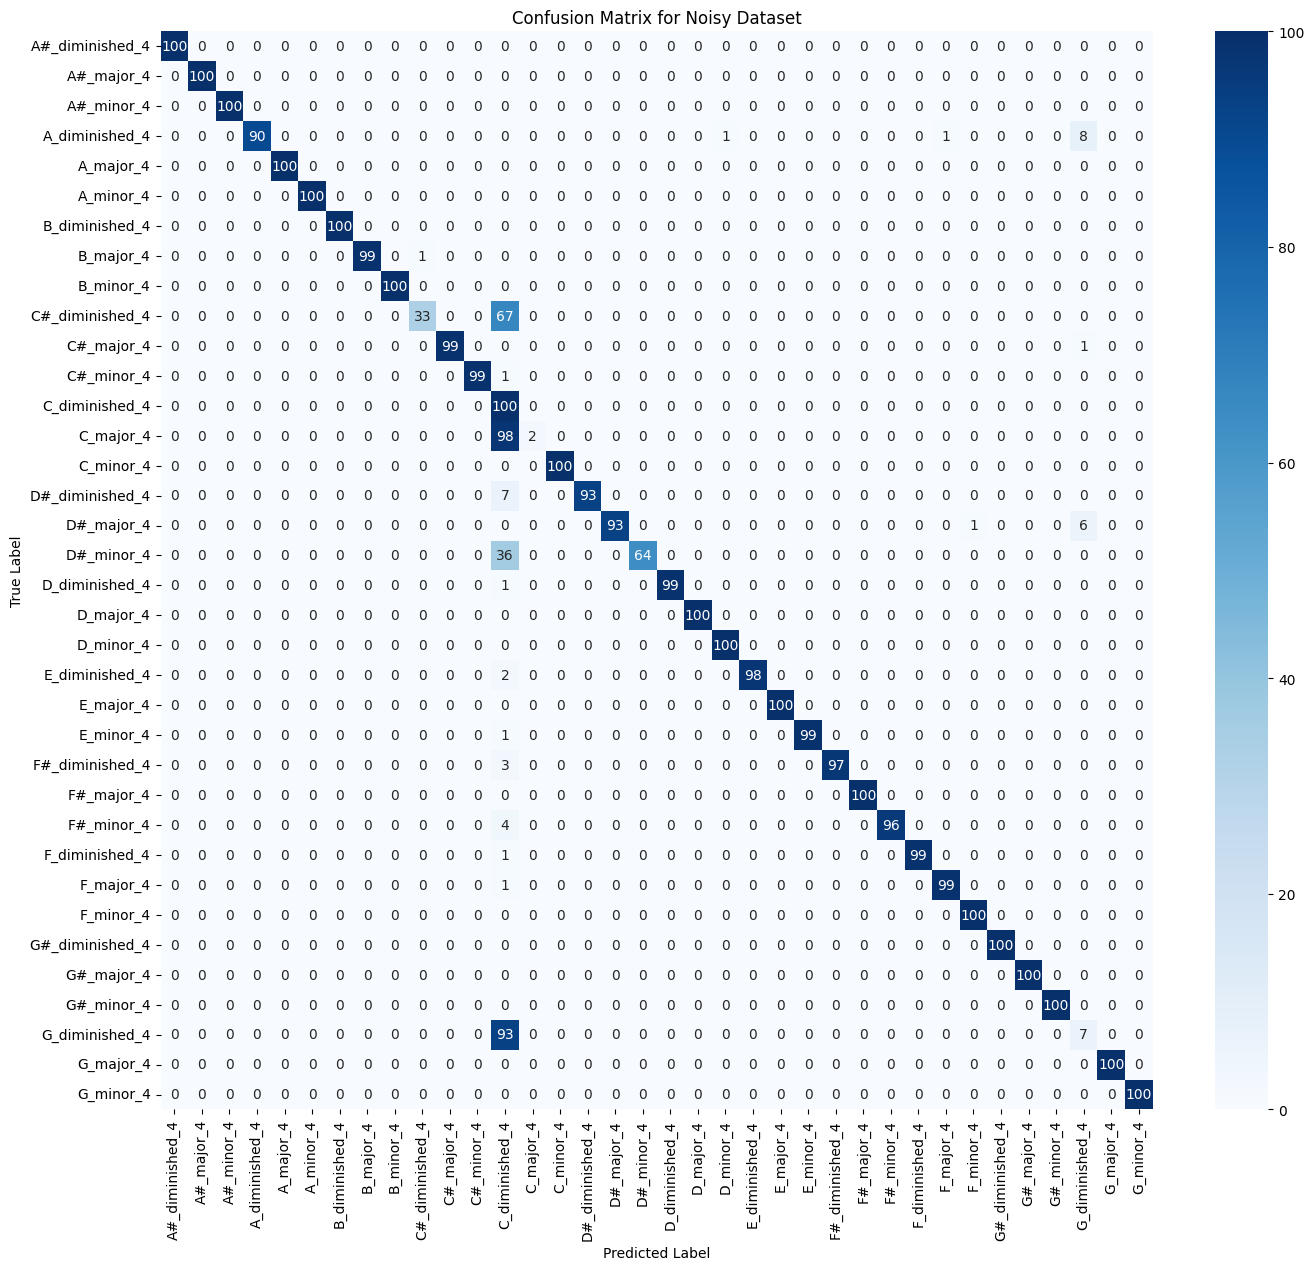


Classification Report for Noisy Dataset:
                  precision    recall  f1-score   support

A#_diminished_4       1.00      1.00      1.00       100
     A#_major_4       1.00      1.00      1.00       100
     A#_minor_4       1.00      1.00      1.00       100
 A_diminished_4       1.00      0.90      0.95       100
      A_major_4       1.00      1.00      1.00       100
      A_minor_4       1.00      1.00      1.00       100
 B_diminished_4       1.00      1.00      1.00       100
      B_major_4       1.00      0.99      0.99       100
      B_minor_4       1.00      1.00      1.00       100
C#_diminished_4       0.97      0.33      0.49       100
     C#_major_4       1.00      0.99      0.99       100
     C#_minor_4       1.00      0.99      0.99       100
 C_diminished_4       0.24      1.00      0.39       100
      C_major_4       1.00      0.02      0.04       100
      C_minor_4       1.00      1.00      1.00       100
D#_diminished_4       1.00      0.93      0.

In [53]:
%%skip_if SKIP_NOISY_TESTS

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Fit label encoder on clean labels (all classes the model was trained on)
noisy_label_encoder = LabelEncoder()
noisy_label_encoder.fit(noisy_labels)
num_classes = len(noisy_label_encoder.classes_)

# Encode noisy labels using the clean label encoder
noisy_encoded_labels = noisy_label_encoder.transform(noisy_labels)
noisy_categorical_labels = to_categorical(noisy_encoded_labels, num_classes=num_classes)

# Reshape noisy_features to add a channel dimension
noisy_features_reshaped = np.expand_dims(noisy_features, axis=-1)

# Get predictions for the noisy test set
noisy_predictions = clean_loaded_model.predict(noisy_features_reshaped)
predicted_noisy_classes = np.argmax(noisy_predictions, axis=1)
actual_noisy_classes = np.argmax(noisy_categorical_labels, axis=1)

# Get class labels from the label encoder
class_labels = noisy_label_encoder.classes_

# Compute the confusion matrix
cm_noisy = confusion_matrix(actual_noisy_classes, predicted_noisy_classes)

# Plot the confusion matrix
plt.figure(figsize=(16, 14))
sns.heatmap(cm_noisy, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Noisy Dataset')
plt.show()

# Generate classification report
report_noisy = classification_report(actual_noisy_classes, predicted_noisy_classes, target_names=class_labels)
print("\nClassification Report for Noisy Dataset:\n", report_noisy)

## Test SVM model

### Load Model

In [54]:
%%skip_if SKIP_NOISY_TESTS

import joblib

svm_model = joblib.load(svm_model_path)
svm_label_encoder = joblib.load(svm_encoder_path)

print(f"SVM model loaded from {svm_model_dir}")
print(f"Classes: {svm_label_encoder.classes_}")

SVM model loaded from ./models-150/svm_model
Classes: ['A#_diminished_4' 'A#_major_4' 'A#_minor_4' 'A_diminished_4' 'A_major_4'
 'A_minor_4' 'B_diminished_4' 'B_major_4' 'B_minor_4' 'C#_diminished_4'
 'C#_major_4' 'C#_minor_4' 'C_diminished_4' 'C_major_4' 'C_minor_4'
 'D#_diminished_4' 'D#_major_4' 'D#_minor_4' 'D_diminished_4' 'D_major_4'
 'D_minor_4' 'E_diminished_4' 'E_major_4' 'E_minor_4' 'F#_diminished_4'
 'F#_major_4' 'F#_minor_4' 'F_diminished_4' 'F_major_4' 'F_minor_4'
 'G#_diminished_4' 'G#_major_4' 'G#_minor_4' 'G_diminished_4' 'G_major_4'
 'G_minor_4']


### Test SVM Model

SVM Test Accuracy on Noisy Dataset: 0.7622

Classification Report:
                  precision    recall  f1-score   support

A#_diminished_4       1.00      0.52      0.68       100
     A#_major_4       1.00      0.99      0.99       100
     A#_minor_4       1.00      1.00      1.00       100
 A_diminished_4       1.00      0.53      0.69       100
      A_major_4       0.98      0.99      0.99       100
      A_minor_4       0.31      1.00      0.48       100
 B_diminished_4       1.00      0.01      0.02       100
      B_major_4       1.00      0.59      0.74       100
      B_minor_4       1.00      1.00      1.00       100
C#_diminished_4       1.00      0.04      0.08       100
     C#_major_4       0.80      0.08      0.15       100
     C#_minor_4       0.64      0.07      0.13       100
 C_diminished_4       0.44      1.00      0.61       100
      C_major_4       0.88      0.07      0.13       100
      C_minor_4       0.00      0.00      0.00       100
D#_diminished_4    

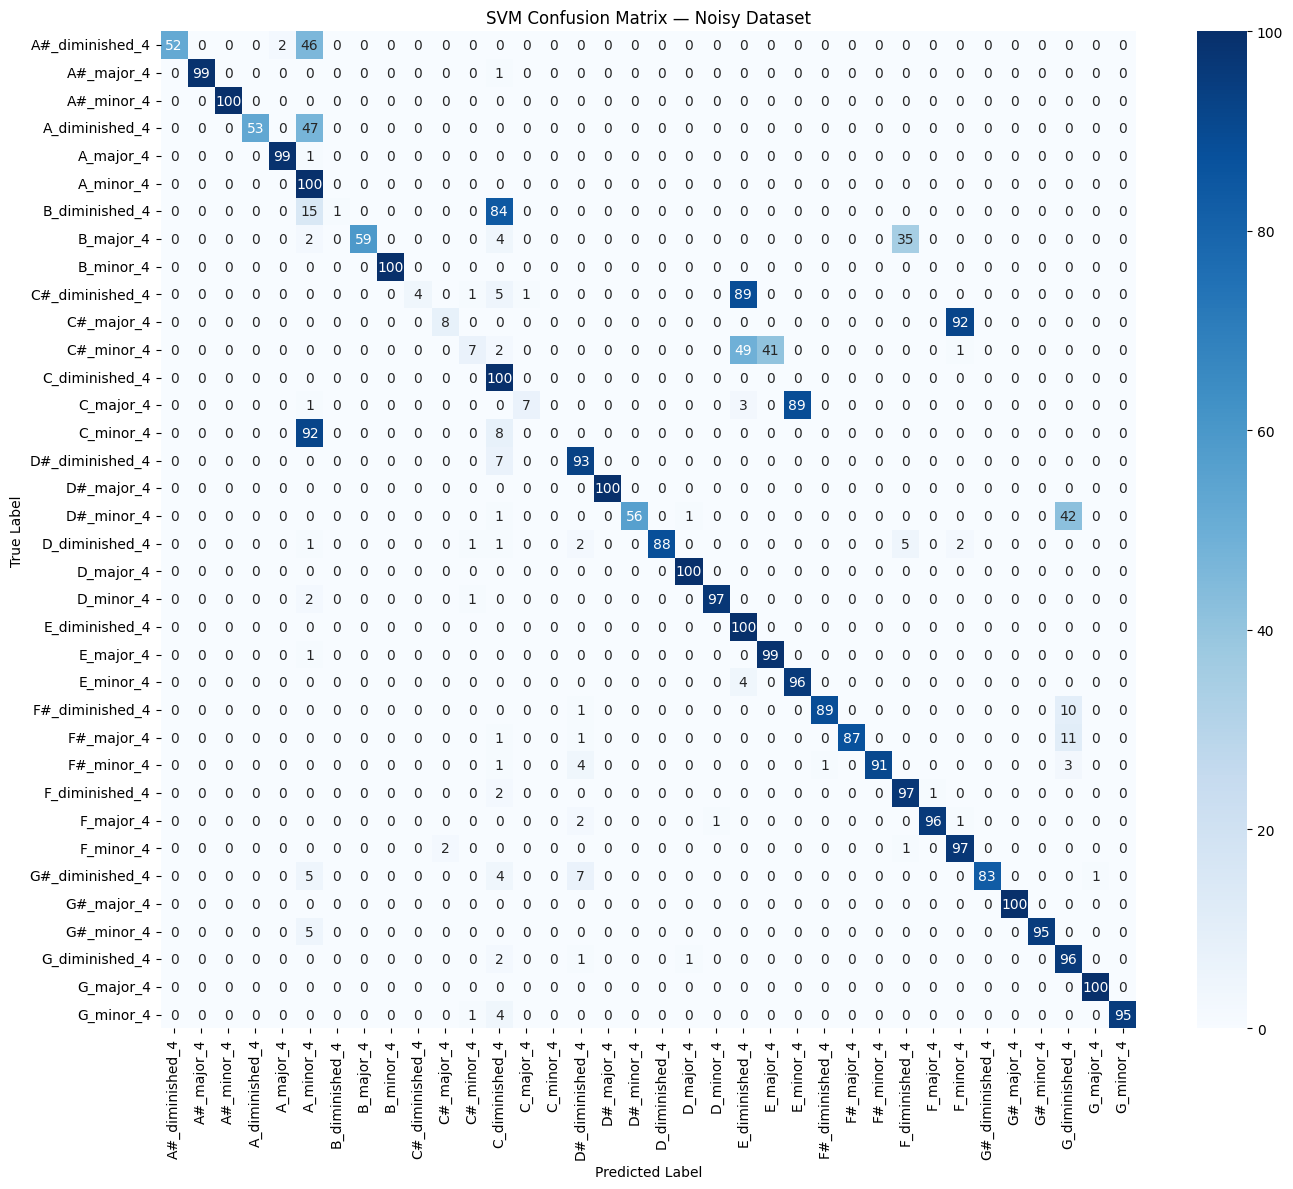

In [55]:
%%skip_if SKIP_NOISY_TESTS

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

noisy_scaler = StandardScaler()

# Flatten and scale noisy features the same way as training data
noisy_features_flat   = noisy_features.reshape(noisy_features.shape[0], -1)
noisy_features_scaled = noisy_scaler.fit_transform(noisy_features_flat)

# Encode noisy labels using the loaded label encoder
noisy_svm_encoded = svm_label_encoder.transform(noisy_labels)

# Predict
y_noisy_pred = svm_model.predict(noisy_features_scaled)

# Accuracy & report
noisy_svm_accuracy = accuracy_score(noisy_svm_encoded, y_noisy_pred)
print(f"SVM Test Accuracy on Noisy Dataset: {noisy_svm_accuracy:.4f}")

svm_class_labels = svm_label_encoder.classes_
report_noisy_svm = classification_report(noisy_svm_encoded, y_noisy_pred, target_names=svm_class_labels)
print("\nClassification Report:\n", report_noisy_svm)

# Confusion matrix
cm_noisy_svm = confusion_matrix(noisy_svm_encoded, y_noisy_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_noisy_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_class_labels, yticklabels=svm_class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix — Noisy Dataset')
plt.tight_layout()
plt.show()

## Compare features

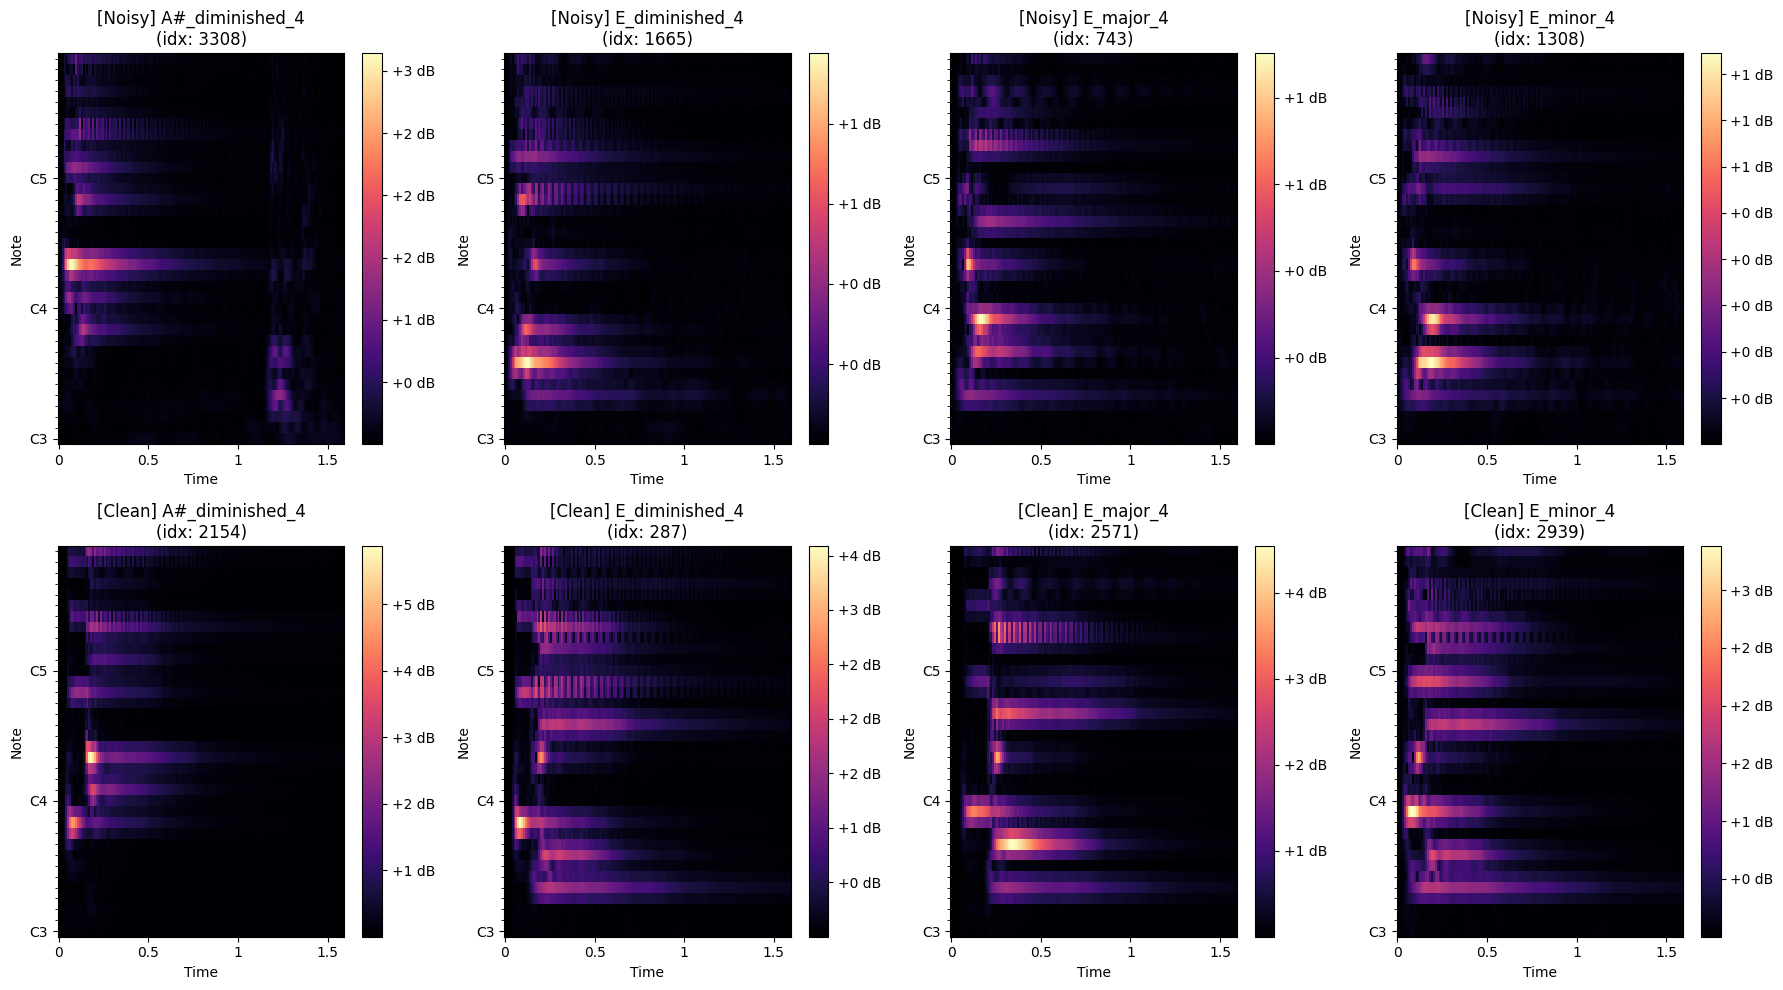


[Noisy] A#_diminished_4 — A#_diminished_4-27.wav


[Clean] A#_diminished_4 — A#_diminished_4-115.wav



[Noisy] E_diminished_4 — E_diminished_4-56.wav


[Clean] E_diminished_4 — E_diminished_4-95.wav



[Noisy] E_major_4 — E_major_4-75.wav


[Clean] E_major_4 — E_major_4-56.wav



[Noisy] E_minor_4 — E_minor_4-73.wav


[Clean] E_minor_4 — E_minor_4-60.wav


In [56]:
%%skip_if SKIP_NOISY_TESTS

import librosa
import numpy as np
from IPython.display import display, Audio
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Seeded RNG for reproducible sample selection
rng = np.random.default_rng(RANDOM_STATE)

target_classes = ['A#_diminished_4', 'E_diminished_4', 'E_major_4', 'E_minor_4']
sr = 48_000
fmin = librosa.note_to_hz('C3')
n_bins = 12 * 3
hop_length = 512

# --- Spectrograms: noisy (top row) and clean (bottom row) ---
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for col, class_name in enumerate(target_classes):
    # Noisy
    noisy_indices = np.where(noisy_labels == class_name)[0]
    noisy_idx = int(rng.choice(noisy_indices))
    noisy_cqt = noisy_features[noisy_idx]

    img = librosa.display.specshow(
        noisy_cqt,
        x_axis='time', y_axis='cqt_note',
        sr=sr, bins_per_octave=12, fmin=fmin, hop_length=hop_length,
        ax=axes[0, col]
    )
    fig.colorbar(img, ax=axes[0, col], format='%+2.0f dB')
    axes[0, col].set_title(f'[Noisy] {class_name}\n(idx: {noisy_idx})')

    # Clean
    clean_indices = np.where(clean_labels == class_name)[0]
    clean_idx = int(rng.choice(clean_indices))
    clean_cqt = clean_features[clean_idx]

    img2 = librosa.display.specshow(
        clean_cqt,
        x_axis='time', y_axis='cqt_note',
        sr=sr, bins_per_octave=12, fmin=fmin, hop_length=hop_length,
        ax=axes[1, col]
    )
    fig.colorbar(img2, ax=axes[1, col], format='%+2.0f dB')
    axes[1, col].set_title(f'[Clean] {class_name}\n(idx: {clean_idx})')

plt.tight_layout()
plt.show()

# --- Audio: noisy then clean for each class ---
for class_name in target_classes:
    # Noisy audio
    noisy_class_dir = os.path.join(dataset_dir_noisy, class_name)
    noisy_audio_files = sorted(os.listdir(noisy_class_dir))
    noisy_audio_file = noisy_audio_files[int(rng.integers(0, len(noisy_audio_files)))]
    noisy_audio_path = os.path.join(noisy_class_dir, noisy_audio_file)

    print(f"\n[Noisy] {class_name} — {noisy_audio_file}")
    y_noisy, sr_noisy = librosa.load(noisy_audio_path, sr=None)
    display(Audio(data=y_noisy, rate=sr_noisy))

    # Clean audio
    clean_class_dir = os.path.join(dataset_dir_clean, class_name)
    clean_audio_files = sorted(os.listdir(clean_class_dir))
    clean_audio_file = clean_audio_files[int(rng.integers(0, len(clean_audio_files)))]
    clean_audio_path = os.path.join(clean_class_dir, clean_audio_file)

    print(f"[Clean] {class_name} — {clean_audio_file}")
    y_clean, sr_clean = librosa.load(clean_audio_path, sr=None)
    display(Audio(data=y_clean, rate=sr_clean))


# Noise reduction

## Test with reduced noise